Mean CH4 conversion at outlet: 0.4387  (eta = 1.0, Nz=50, Nr=20)


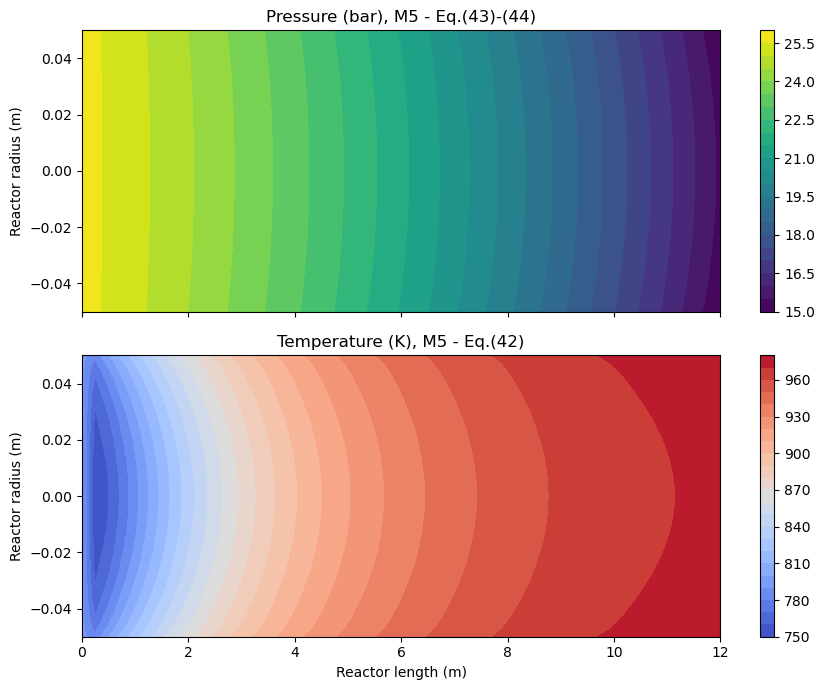

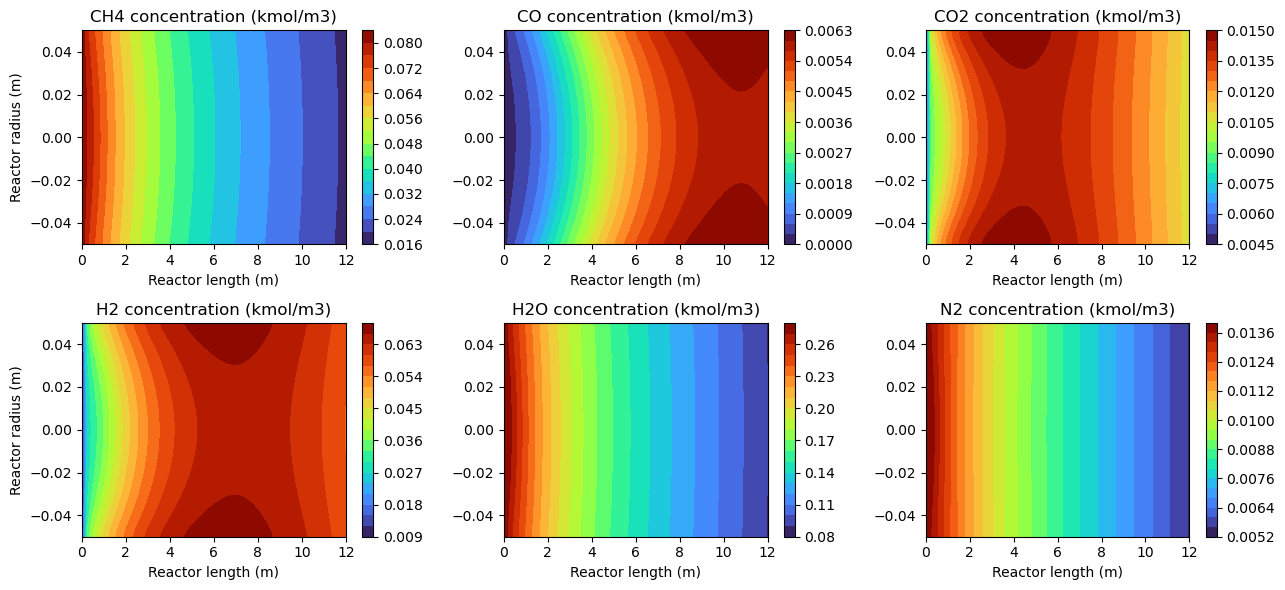

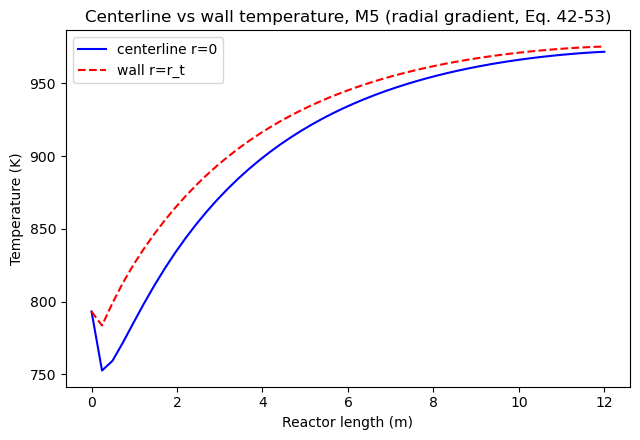

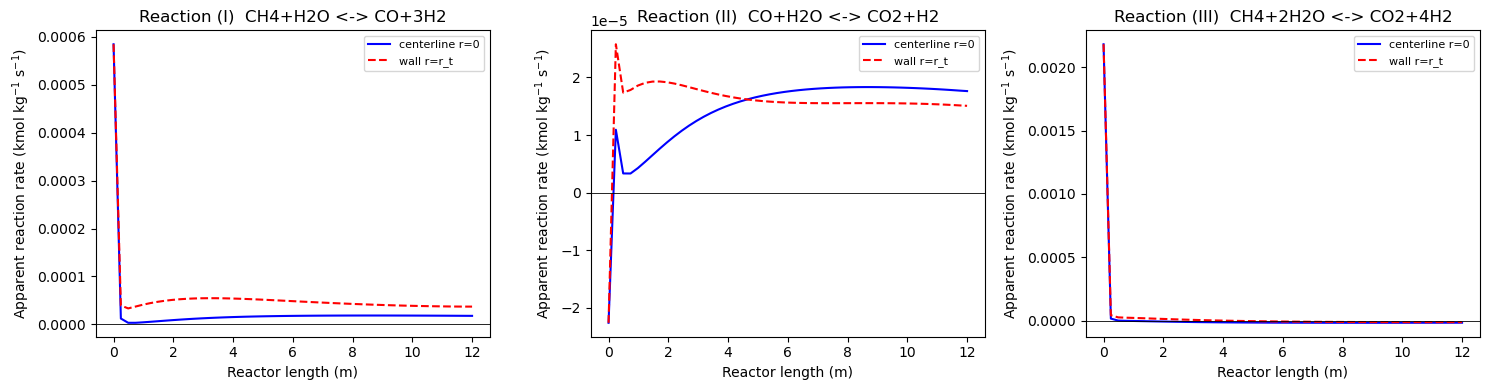

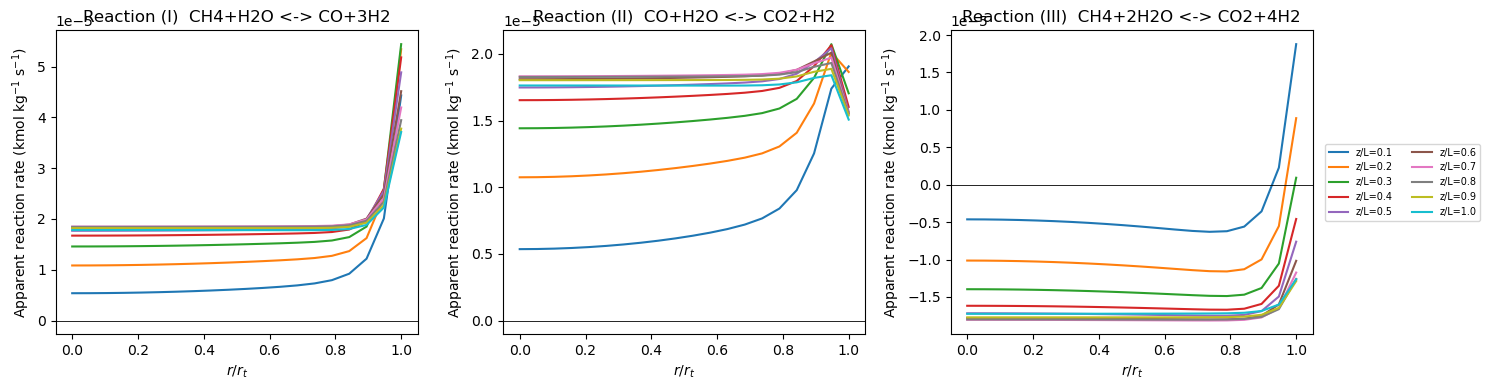

Mean CH4 conversion at outlet: 0.4387  (eta = 1.0, Nz=50, Nr=20)


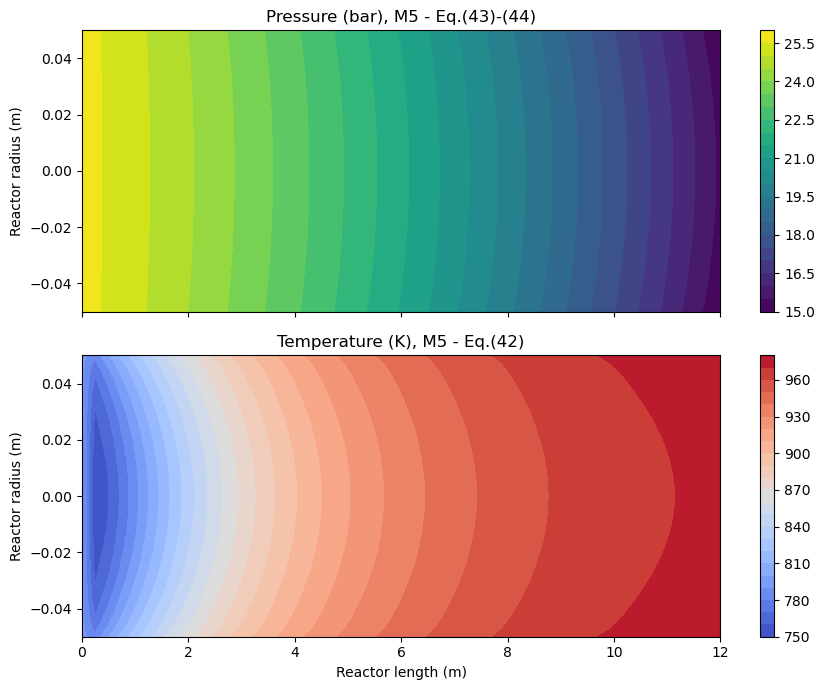

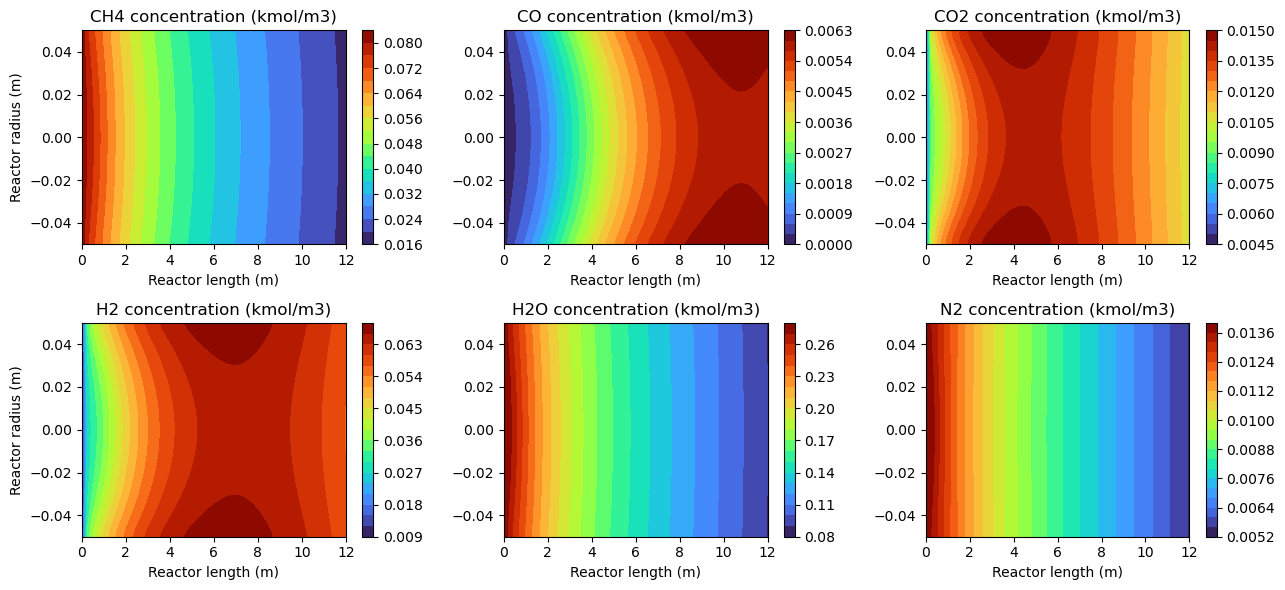

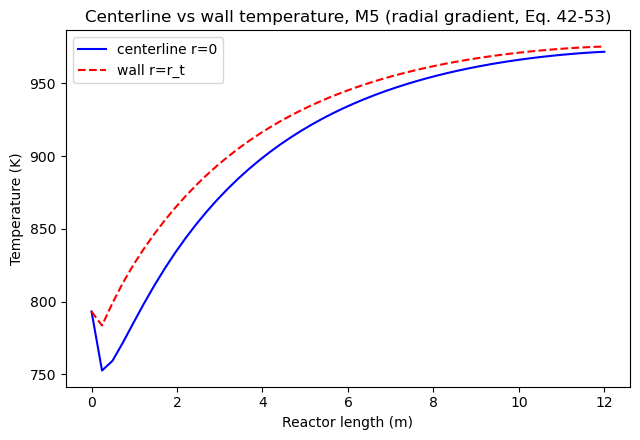

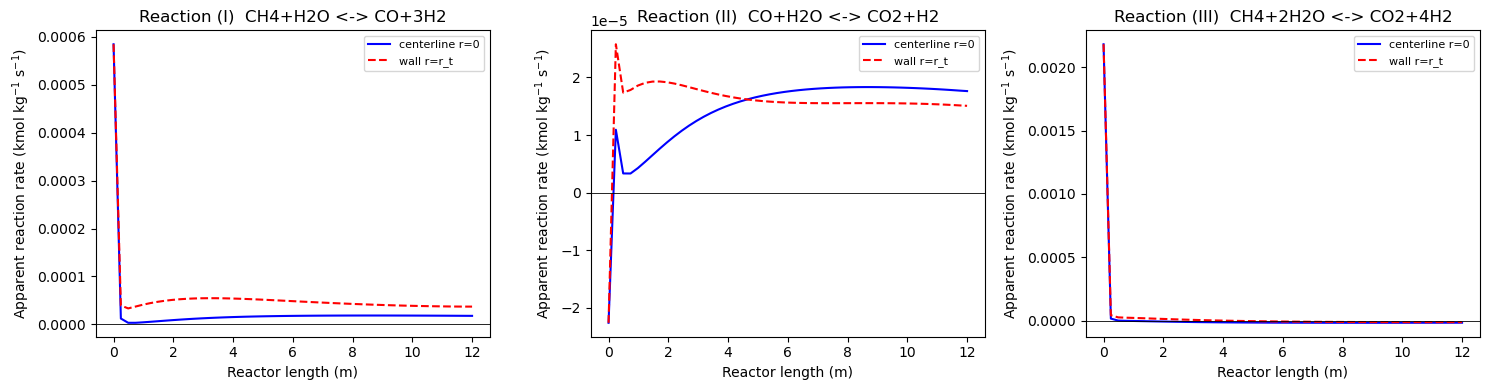

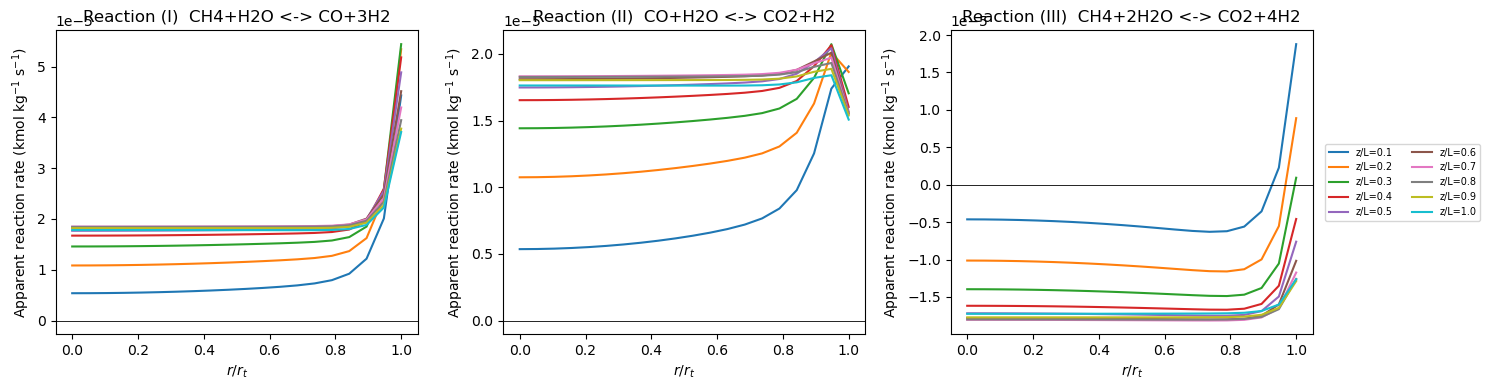

Mean CH4 conversion at outlet: 0.4387  (eta = 1.0, Nz=50, Nr=20)


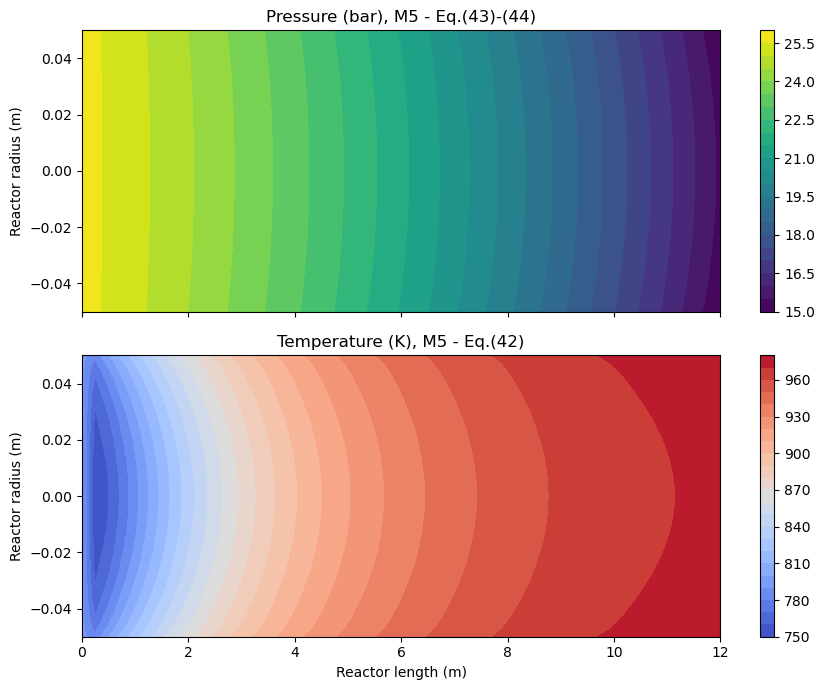

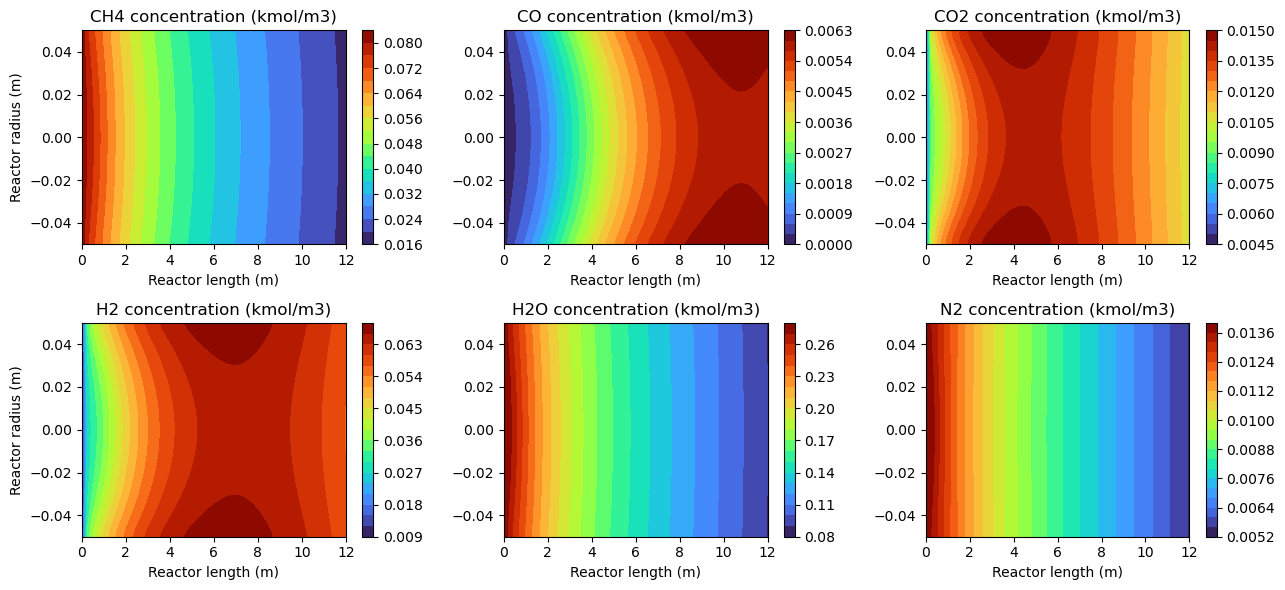

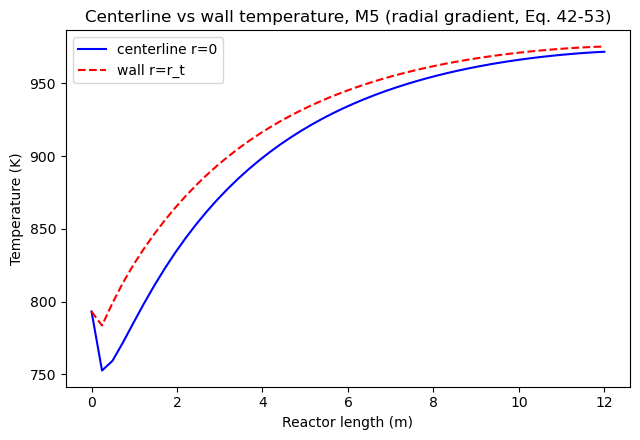

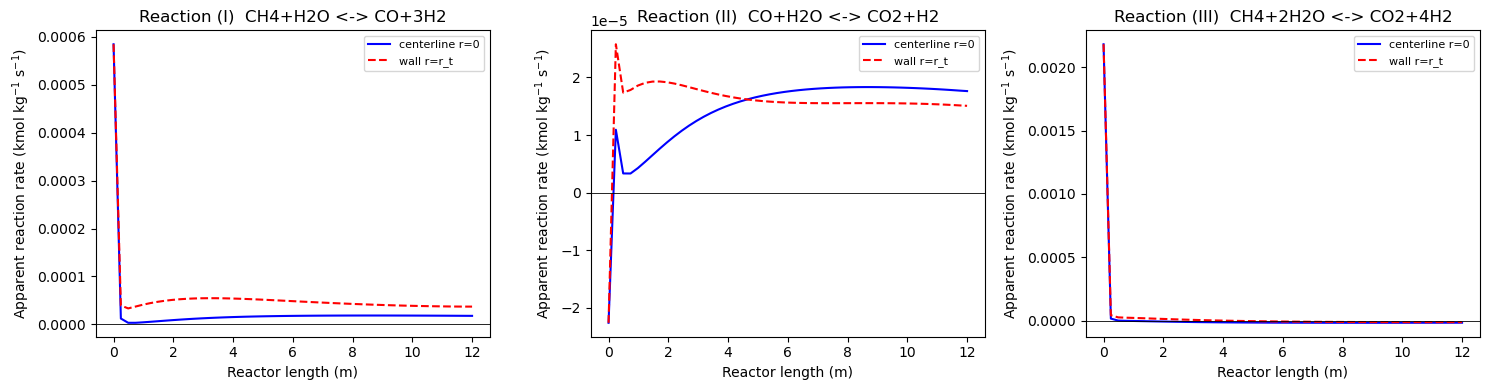

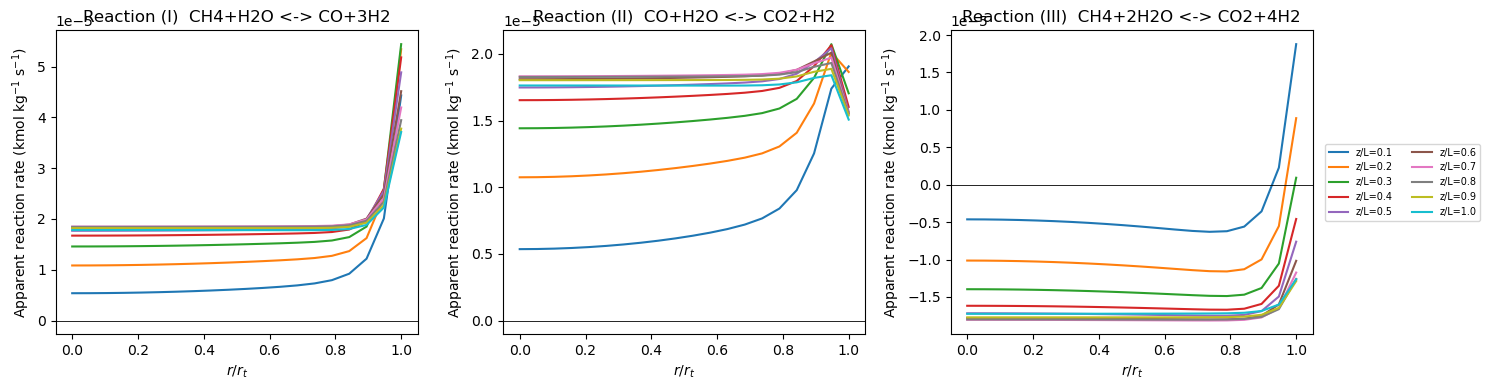

Mean CH4 conversion at outlet: 0.4387  (eta = 1.0, Nz=50, Nr=20)


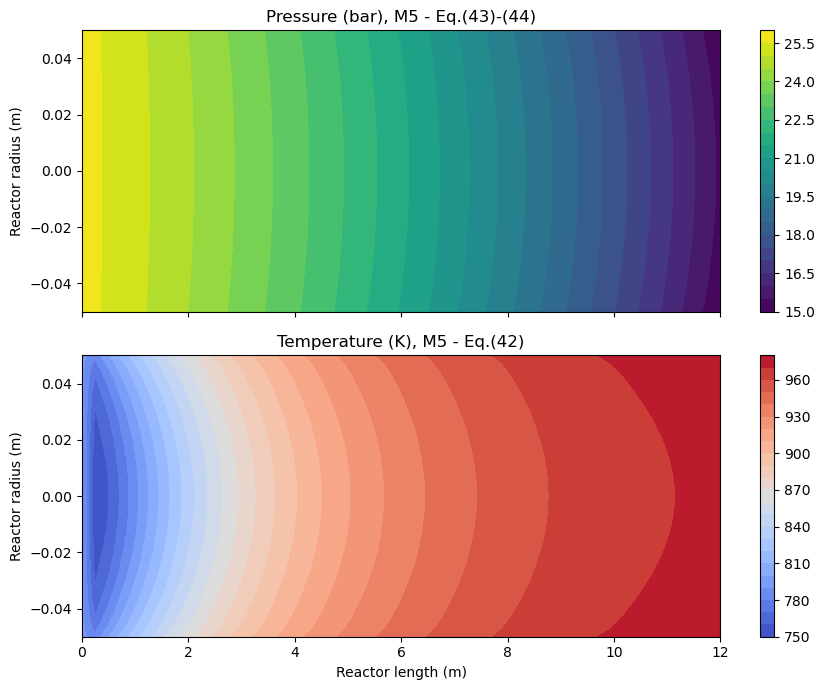

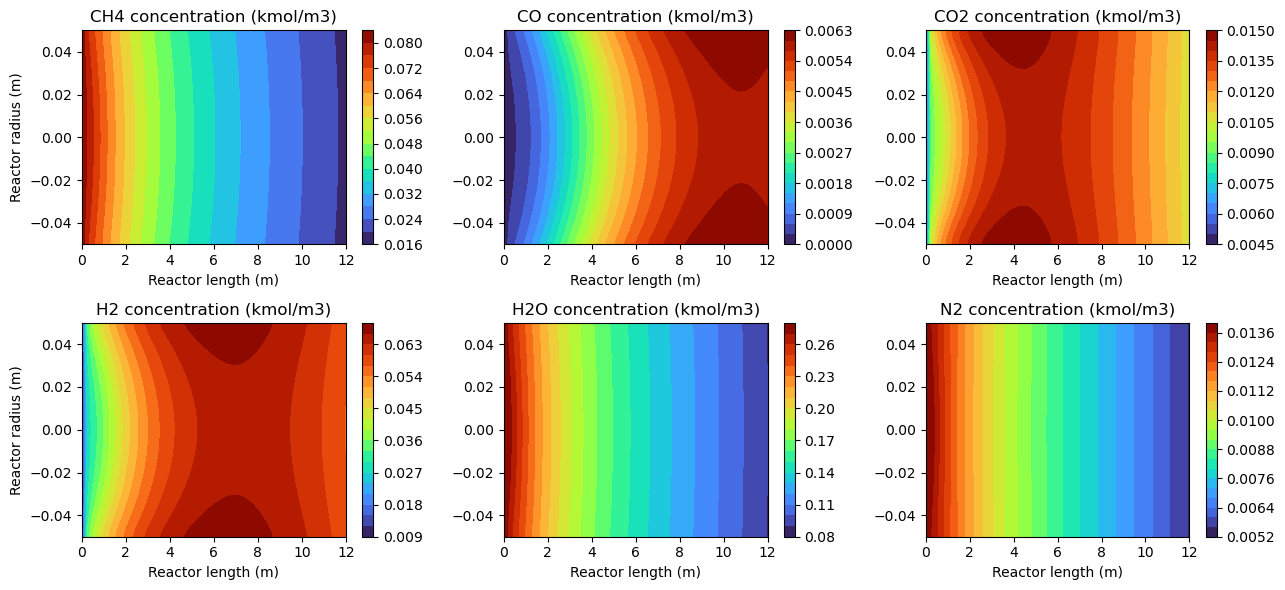

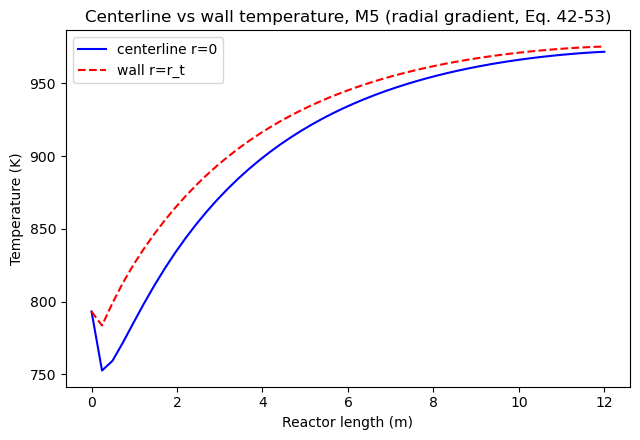

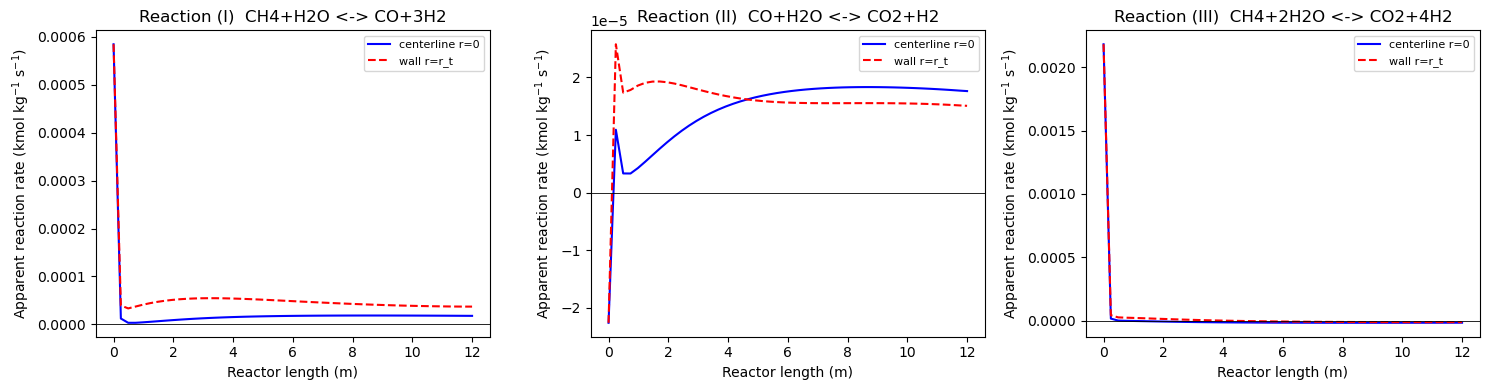

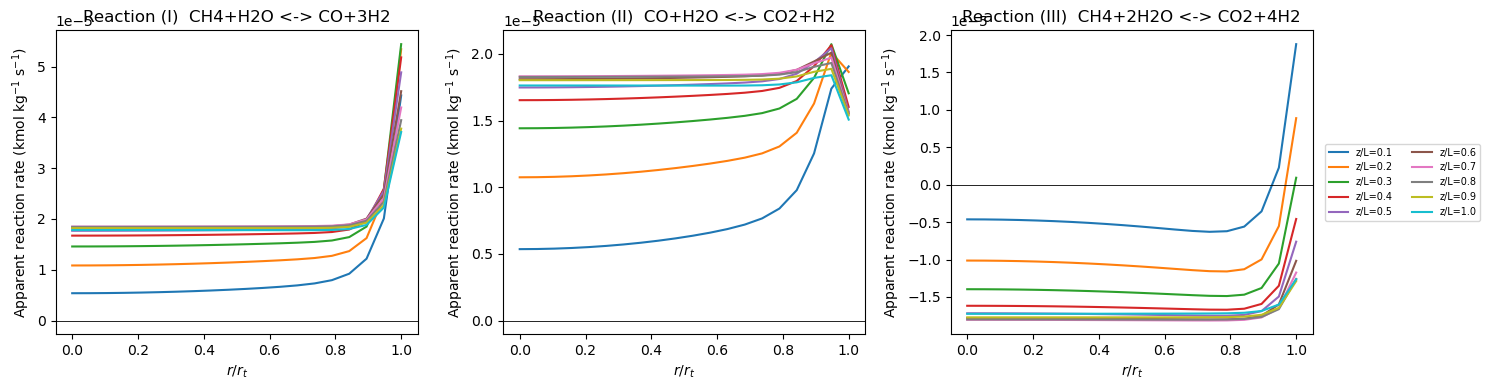

Mean CH4 conversion at outlet: 0.4387  (eta = 1.0, Nz=50, Nr=20)


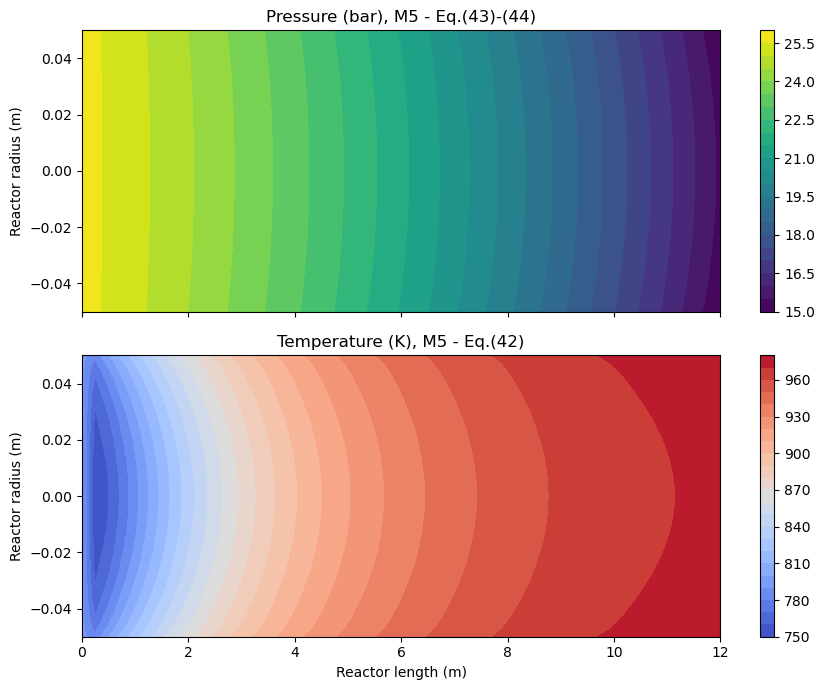

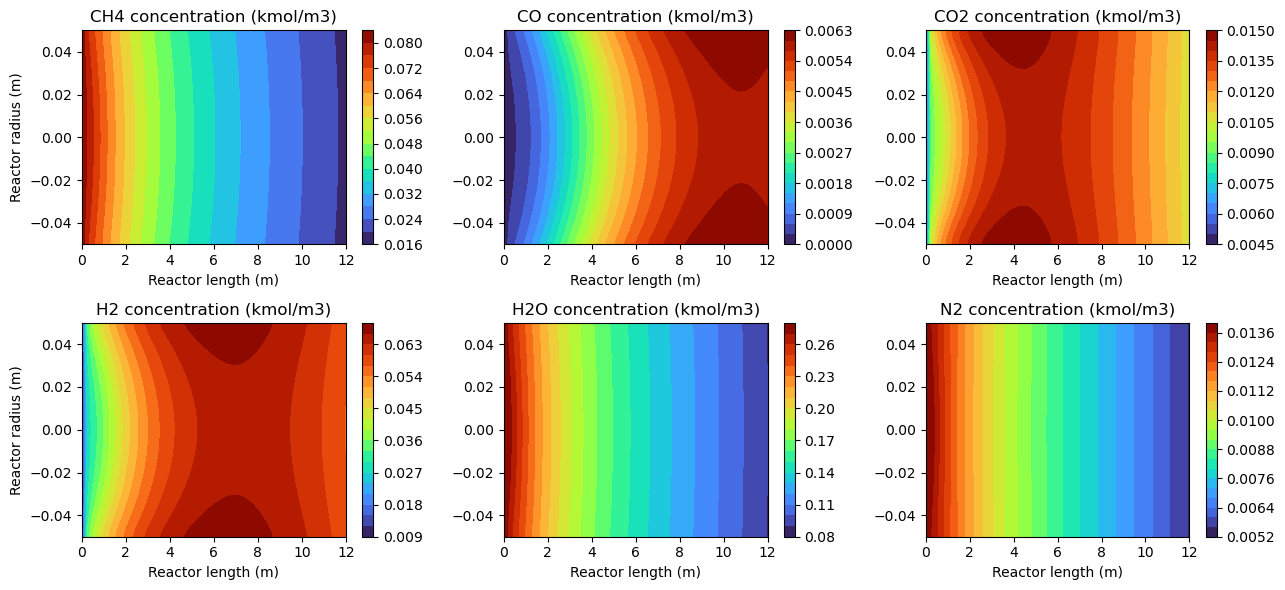

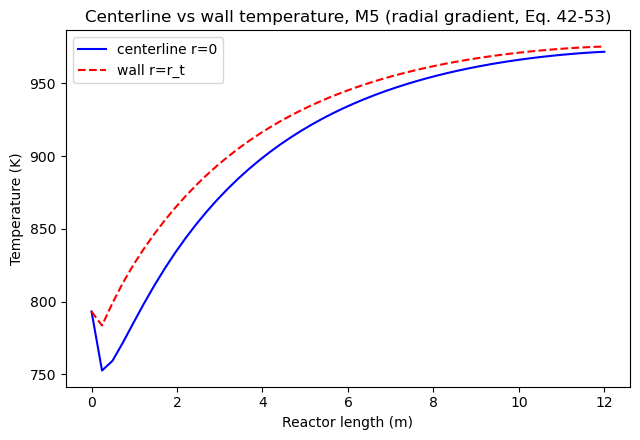

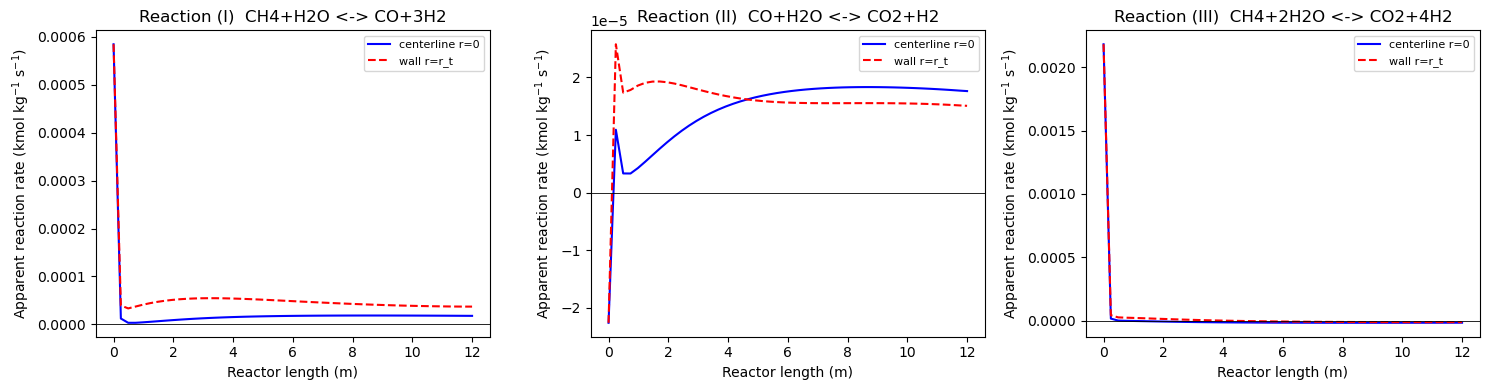

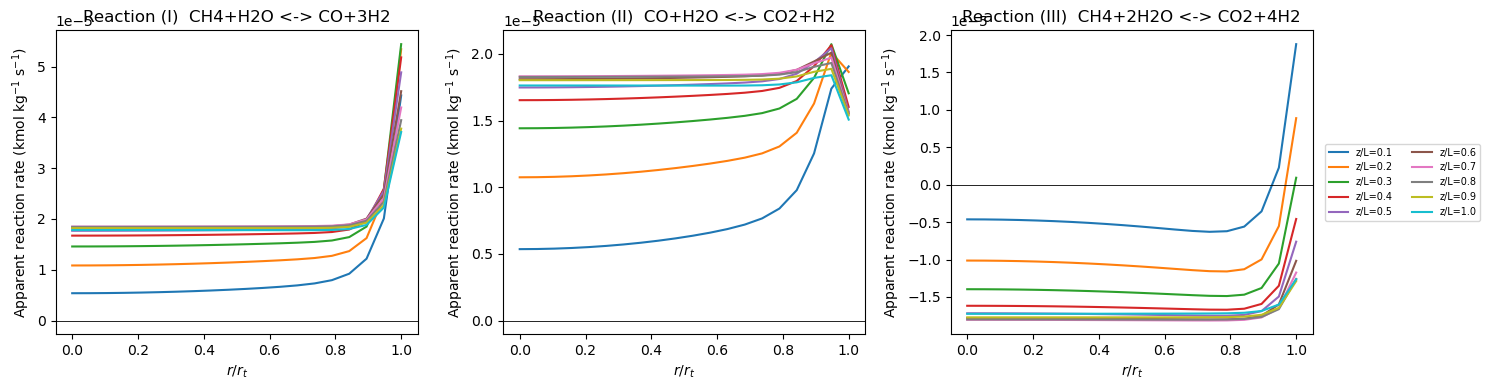

Mean CH4 conversion at outlet: 0.4387  (eta = 1.0, Nz=50, Nr=20)


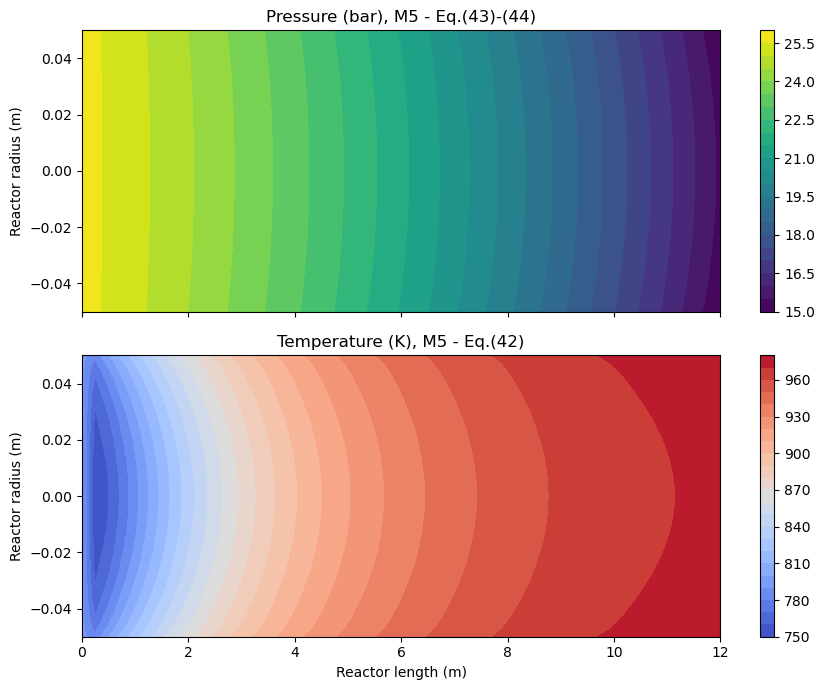

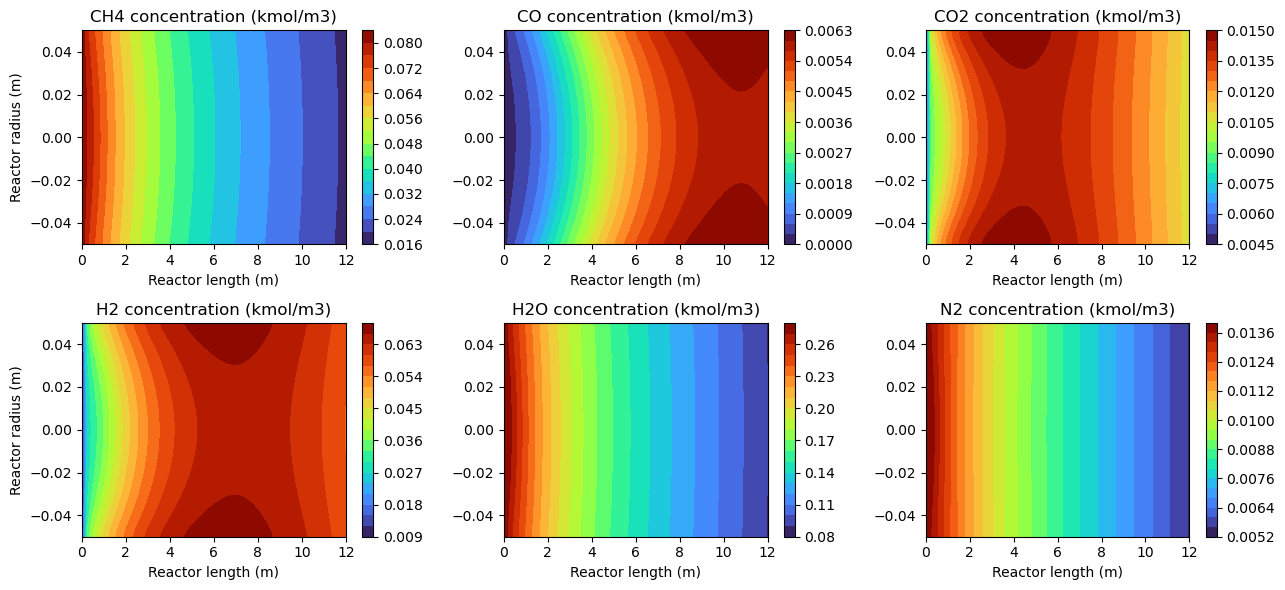

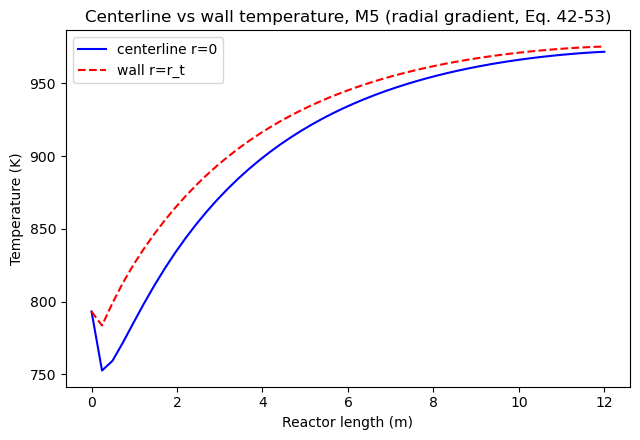

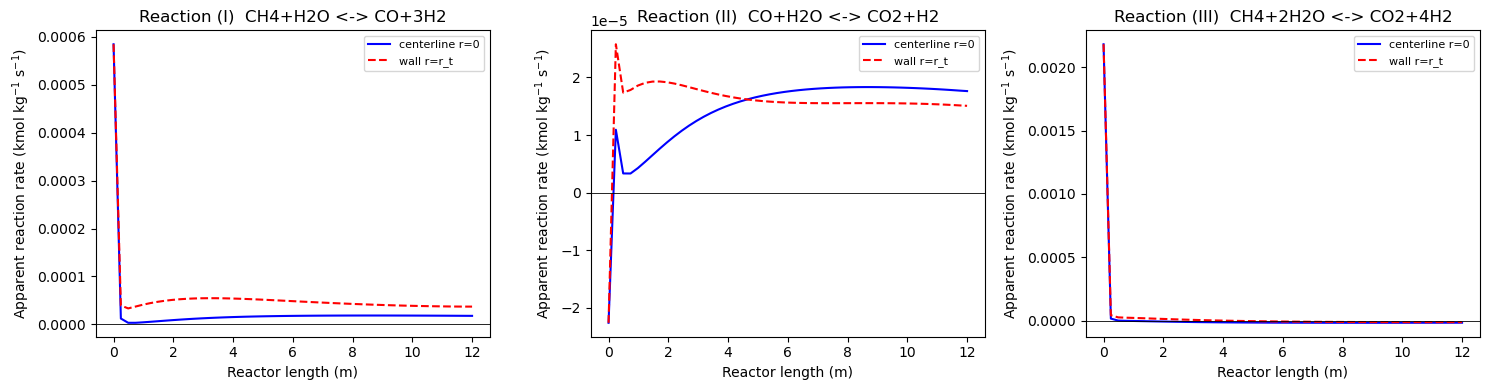

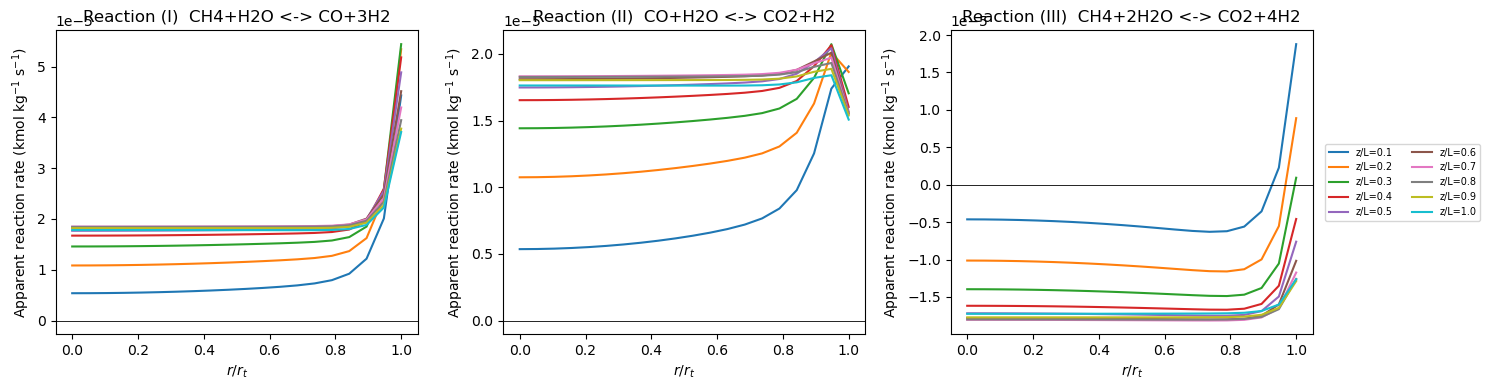

Mean CH4 conversion at outlet: 0.4387  (eta = 1.0, Nz=50, Nr=20)


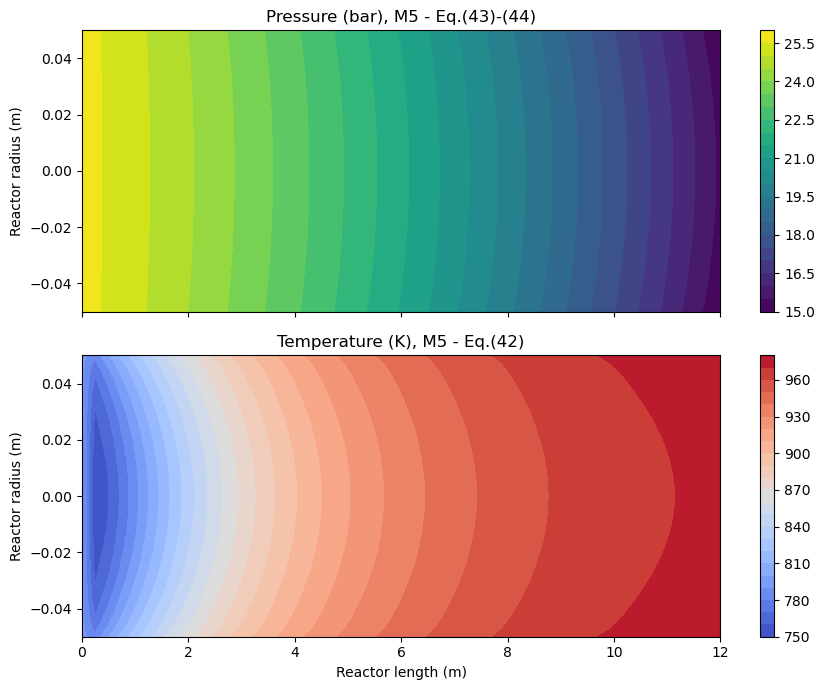

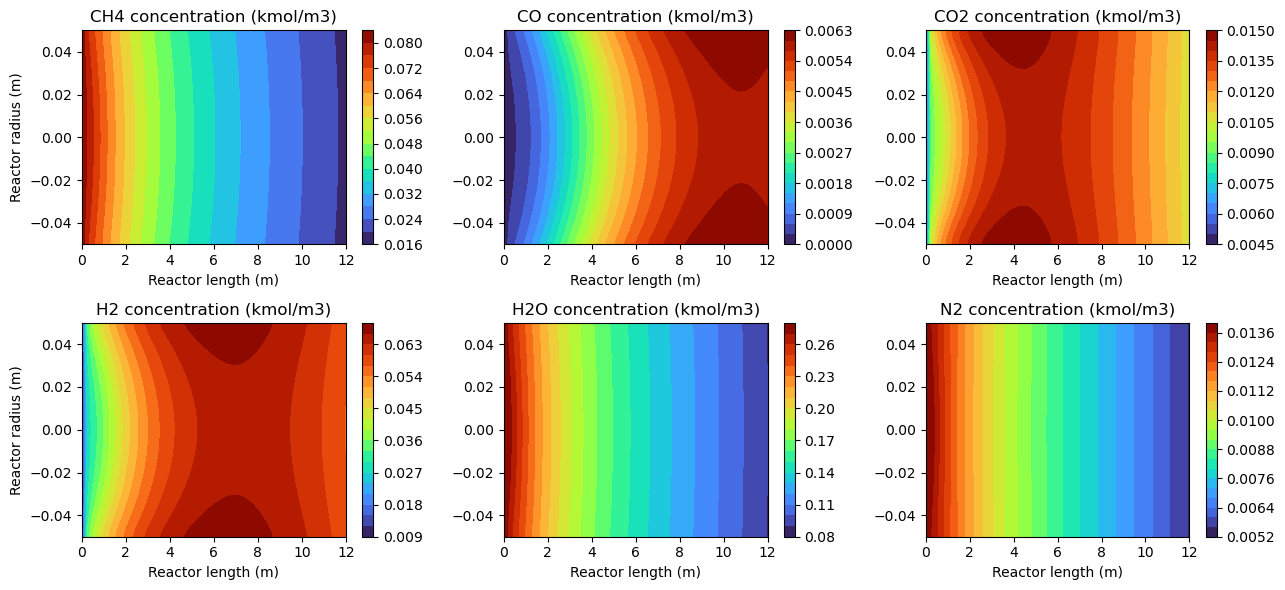

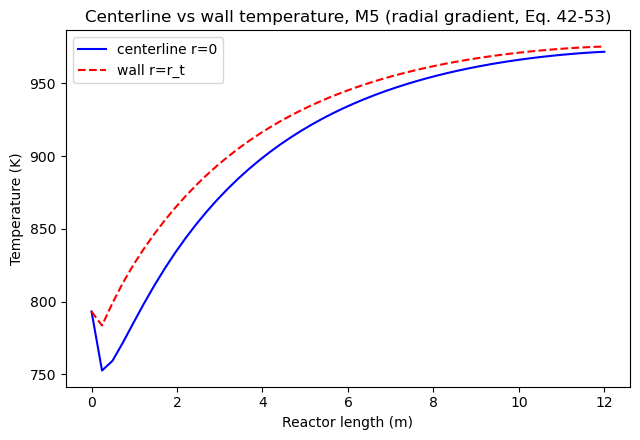

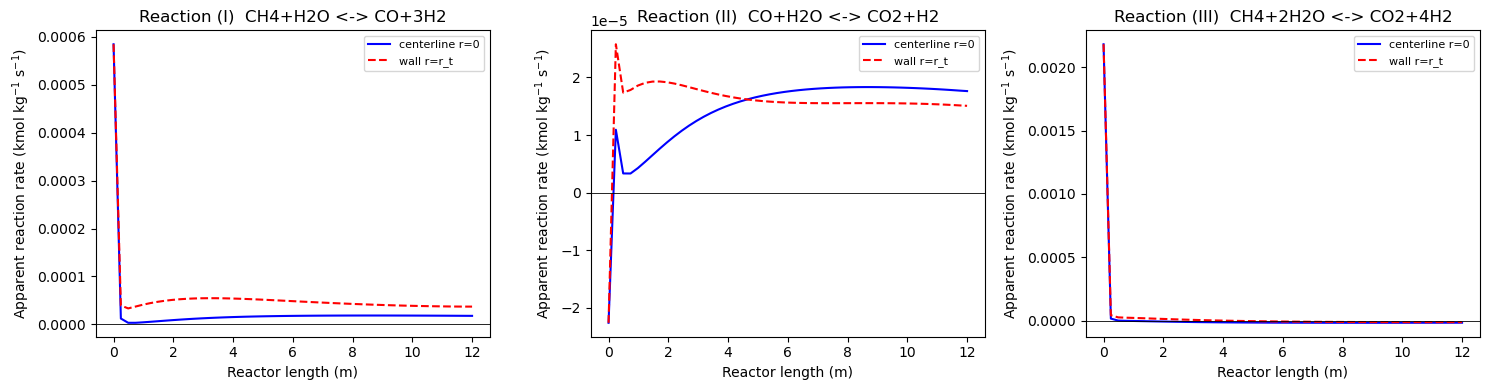

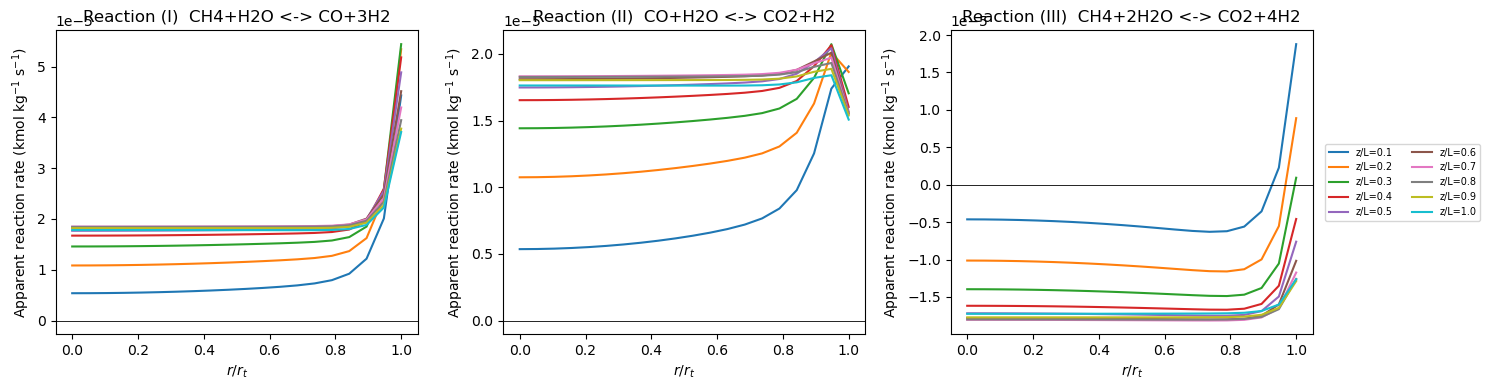

Mean CH4 conversion at outlet: 0.4387  (eta = 1.0, Nz=50, Nr=20)


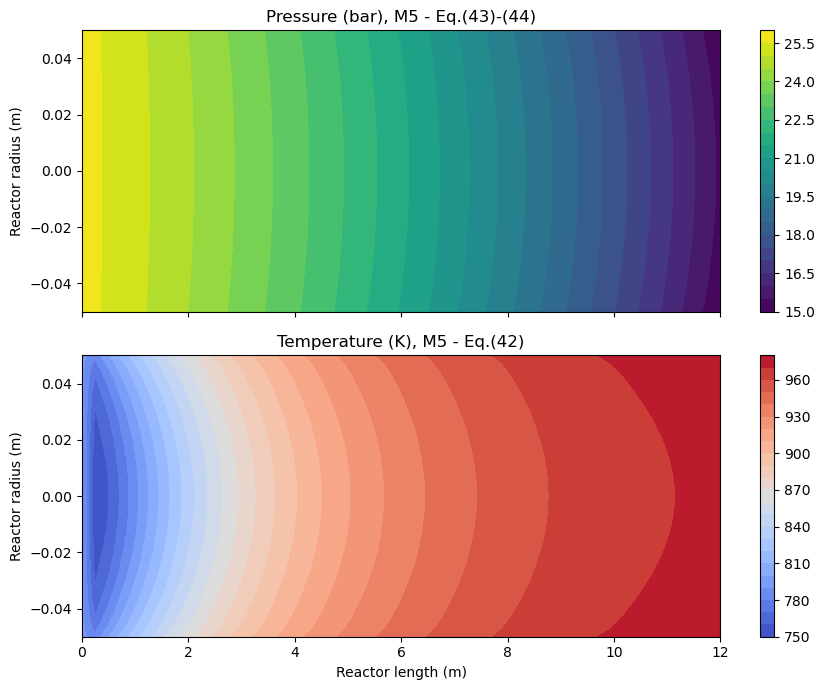

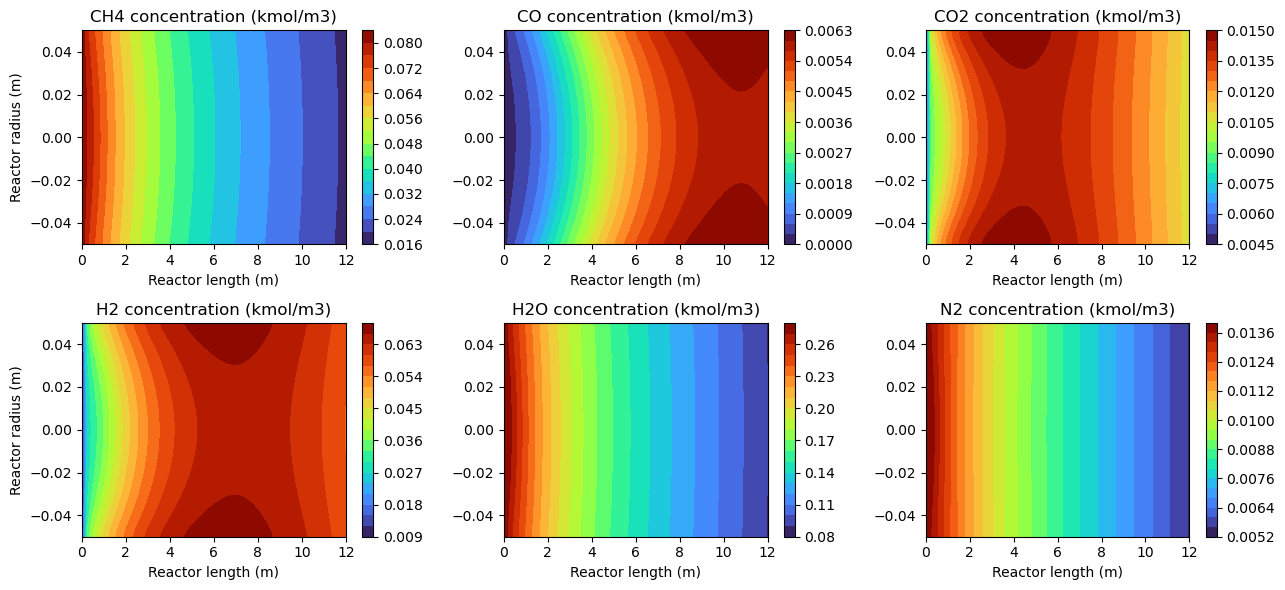

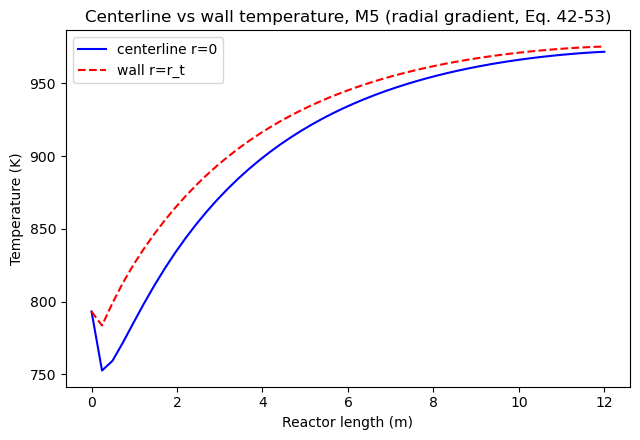

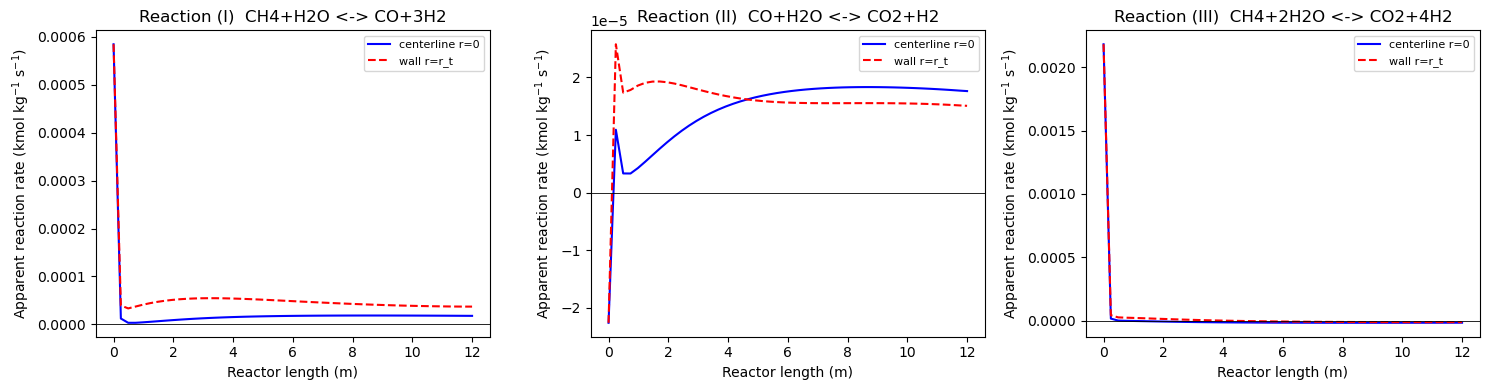

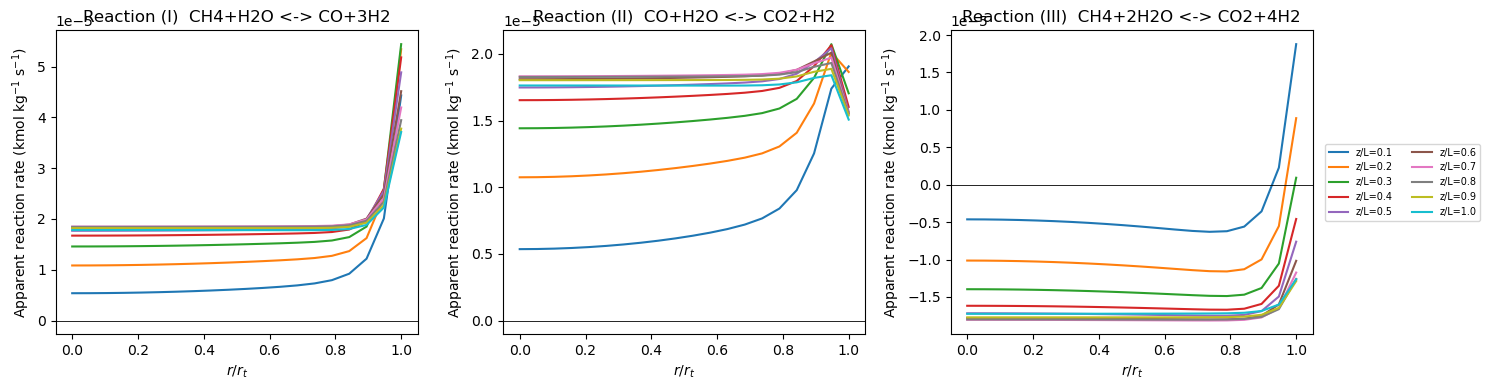

5min 36s ± 3.4 s per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [2]:
%%timeit

import numpy as np
from scipy.integrate import solve_ivp
from scipy.sparse import diags, kron, identity, csr_matrix
import matplotlib
import matplotlib.pyplot as plt

# ============================================================================
# 1. OPERATING / GEOMETRIC DATA  (Table 2)
# ============================================================================
Rg      = 8.314                # J/mol/K
Rg_bar  = 0.08314               # bar.m3/(kmol.K)  (= 8314 J/(kmol.K) in bar.m3 units)
Rg_kJ   = 8.314e-3              # kJ/mol/K  (Arrhenius / van't Hoff exponents, App. A)

L       = 12.0                  # m,    reactor length                 Table 2
dt_tube = 0.10                   # m,    tube inner diameter            Table 2
rt      = dt_tube/2.0             # m,    tube inner radius (r_t in Eqs. 41-61)
dp      = 0.01                    # m,    catalyst particle diameter     Table 2
rho_p   = 2355.2                   # kg/m3, catalyst density             Table 2
Cp_p    = 950.0                     # J/(kg.K), catalyst heat capacity   Table 2
lam_p   = 0.3489                     # W/(m.K), catalyst solid conductivity Table 2
T0      = 793.15                      # K,   inlet temperature           Table 2
P0      = 25.69                        # bar, inlet pressure             Table 2
Tw      = 1000.0                        # K,  constant tube-wall T (Assumption 7)
eps_p   = 0.519                          # catalyst pellet porosity  (App. B.3, unused directly in M5)
tau_p   = 2.74                            # catalyst tortuosity       (App. B.3, unused directly in M5)

species = ['CH4', 'CO', 'CO2', 'H2', 'H2O', 'N2']
MW = {'CH4':16.0428,'CO':28.0104,'CO2':44.0098,'H2':2.01588,'H2O':18.0153,'N2':28.0135}   # Table C.1

F0_h = {'CH4':5.17,'CO':0.0,'CO2':0.29,'H2':0.63,'H2O':17.35,'N2':0.85}                    # kmol/h, Table 2
F0   = {k: v/3600.0 for k, v in F0_h.items()}                                               # -> kmol/s

# Bed voidage,   Eq.(3)
eps_b = 0.38 + 0.073*(1.0 - (dt_tube/dp - 2.0)**2 / (dt_tube/dp)**2)

# Cross-sectional area,  Eq.(7)
Omega = np.pi*dt_tube**2/4.0

# Inlet superficial velocity,  Eq.(8)
F0_tot = sum(F0.values())
Uz0 = F0_tot*Rg_bar*T0/(Omega*P0)                 # m/s
rho_g0 = sum(F0[s]*MW[s] for s in species)/(Uz0*Omega)   # kg/m3
G0 = rho_g0*Uz0        # kg/(m2.s). CONSTANT mass flux everywhere in (z,r): see header note
                       # on why u_r=0 + uniform inlet => G(z,r) = G0 exactly (Eq. 44).

# Inlet concentrations,  Eq.(6) rearranged: C_i0 = F_i0/(Uz0*Omega)
C0 = np.array([F0[s]/(Uz0*Omega) for s in species])       # kmol/m3

# Effectiveness factor (constant, pseudo-homogeneous simplification, Eq.1 / Sec.4.1.2)
ETA = 1.0        # set to 1, 0.1, 0.01, or 0.001 to reproduce the paper's Table 3 sweep

MWv = np.array([MW[s] for s in species])

# ============================================================================
# 2. KINETIC PARAMETERS - Xu & Froment (1989), Appendix A, Table A.1
# ============================================================================
Ak  = {1: 4.225e15/3600.0, 2: 1.955e6/3600.0, 3: 1.020e15/3600.0}   # kmol/(kgcat.s) [/3600: h->s]
E_a = {1: 240.1, 2: 67.13, 3: 243.9}                                 # kJ/mol
AK  = {1: 4.707e12, 2: 1.142e-2, 3: 5.375e10}
dH298 = {1: 206.1, 2: -41.15, 3: 164.9}                              # kJ/mol, Table A.1 dHrxn,j(298K):
                                                                       # used ONLY as the base value in Eq.(A.7)'s
                                                                       # Cp integration (the equation explicitly
                                                                       # integrates FROM 298K), i.e. for the
                                                                       # energy-balance heat-of-reaction term.
dH948 = {1: 224.0, 2: -37.3, 3: 187.5}                               # kJ/mol, Table A.1 dHrxn,j(948K):
                                                                       # used as the fixed reference enthalpy inside
                                                                       # Eq.(A.6)'s equilibrium constant K_j, since
                                                                       # this reactor operates at 793-1000K - much
                                                                       # closer to 948K than to 298K. Table A.1
                                                                       # tabulates both; 948K is the one inside the
                                                                       # actual operating range, so it is used here.
AKi = {'CO':8.23e-5, 'H2':6.12e-9, 'CH4':6.65e-4, 'H2O':1.77e5}      # bar^-1 (H2O dimensionless)
dHi = {'CO':-70.65, 'H2':-82.90, 'CH4':-38.28, 'H2O':88.68}          # kJ/mol   Eq.(A.8) exponent

# Heat-capacity polynomial coefficients (J/mol/K), Table C.5,  Eq.(C.10)
CP = {
    'CH4': (34.942, -3.9957e-2, 1.9184e-4, -1.5303e-7, 3.9321e-11),
    'CO' : (29.556, -6.5807e-3, 2.0130e-5, -1.2227e-8, 2.2617e-12),
    'CO2': (27.437,  4.2315e-2,-1.9555e-5,  3.9968e-9,-2.9872e-13),
    'H2' : (25.399,  2.0178e-2,-3.8549e-5,  3.1880e-8,-8.7585e-12),
    'H2O': (33.933, -8.4186e-3, 2.9906e-5, -1.7825e-8, 3.6934e-12),
    'N2' : (29.342, -3.5395e-3, 1.0076e-5, -4.3116e-9, 2.5935e-13),
}
# Reaction stoichiometry (nu_ij) for the 3 reactions, used in Eq.(41) & Eq.(A.7)
NU = {  # {species: [nu_I, nu_II, nu_III]}
    'CH4': [-1, 0, -1], 'CO': [1, -1, 0], 'CO2': [0, 1, 1],
    'H2': [3, 1, 4], 'H2O': [-1, -1, -2], 'N2': [0, 0, 0]}
NU_MAT = np.array([NU[s] for s in species])          # (6,3)

# Viscosity correlation coefficients (micropoise, T in K), Table C.2, Eq.(C.3)
VISC = {
    'CH4': (3.844, 4.0112e-1, -1.4303e-4), 'CO': (23.811, 5.3944e-1, -1.5411e-4),
    'CO2': (11.811, 4.9838e-1, -1.0851e-4), 'H2': (27.758, 2.1200e-1, -3.2800e-5),
    'H2O': (-36.826, 4.2900e-1, -1.6200e-5), 'N2': (42.606, 4.7500e-1, -9.8800e-5)}

# Thermal conductivity correlation coefficients (W/m/K, T in K), Table C.4, Eq.(C.8)
LAMG = {
    'CH4': (-0.00935, 1.4028e-4, 3.3180e-8), 'CO': (0.00158, 8.2511e-5, -1.9081e-8),
    'CO2': (-0.01200, 1.0208e-4, -2.2403e-8), 'H2': (0.03951, 4.5918e-4, -6.4933e-8),
    'H2O': (0.00053, 4.7093e-5, 4.9551e-8), 'N2': (0.00309, 7.5930e-5, -1.1014e-8)}

# Critical properties, Table C.3, used in Eq.(C.5)-(C.7)
TC = {'CH4':190.58,'CO':132.92,'CO2':304.19,'H2':33.18,'H2O':647.13,'N2':126.10}   # K
PC = {'CH4':46.04, 'CO':34.99, 'CO2':73.82, 'H2':13.13, 'H2O':220.55,'N2':33.94}    # bar

# Lennard-Jones parameters, Table B.1, used in Eq.(B.19)-(B.22)
LJ_SIGMA = {'CH4':3.758,'CO':3.690,'CO2':3.941,'H2':2.827,'H2O':2.641,'N2':3.798}   # Angstrom
LJ_EPSK  = {'CH4':148.6,'CO':91.7 ,'CO2':195.2,'H2':59.7 ,'H2O':809.1,'N2':71.4 }    # K

# ============================================================================
# 3. PHYSICAL-PROPERTY / TRANSPORT FUNCTIONS  (Appendices B & C)
#    Every function below is written elementwise/broadcasting-generic: T and
#    ymol may be shape (Nz,) (1D models) or (Nr,Nz) (this 2D M5 model) -
#    the SAME code path handles both, which is what keeps the RHS free of
#    explicit Python loops over the spatial grid.
# ============================================================================
def cp_i_molar(T, sp):
    """Eq.(C.10): pure-component molar Cp [J/mol/K]"""
    A, B, C, D, E = CP[sp]
    return A + B*T + C*T**2 + D*T**3 + E*T**4

def mu_i(T, sp):
    """Eq.(C.3): pure-component viscosity [micropoise]"""
    A, B, C = VISC[sp]
    return A + B*T + C*T**2

def lam_i(T, sp):
    """Eq.(C.8): pure-component thermal conductivity [W/m/K]"""
    A, B, C = LAMG[sp]
    return A + B*T + C*T**2

def _bshape(T):
    """Broadcast helper: (n_species,) + (1,)*T.ndim so a per-species 1D
    vector can be multiplied into a (n_species,)+T.shape array regardless
    of whether T is 1D (Nz,) or 2D (Nr,Nz)."""
    return (len(species),) + (1,)*np.ndim(T)

def mu_mix(T, ymol):
    """Gas mixture viscosity, Eq.(C.1)-(C.2)  -> Pa.s"""
    mus = np.array([mu_i(T, s) for s in species])          # (6,)+T.shape
    out = np.zeros_like(T)
    for i, si in enumerate(species):
        phij = np.sqrt(MWv/MW[si])                          # phi_ij=(Mj/Mi)^0.5, Eq.(C.2)
        denom = np.sum(ymol*phij.reshape(_bshape(T)), axis=0)
        out += ymol[i]*mus[i]/denom
    return out*1e-7   # micropoise -> Pa.s

def lambda_mix(T, ymol):
    """Gas mixture thermal conductivity, Eq.(C.4)-(C.7)  -> W/m/K"""
    lams = np.array([lam_i(T, s) for s in species])
    Tr = {s: T/TC[s] for s in species}
    gam = {s: 210.0*(TC[s]*MW[s]**3/PC[s]**4)**(1.0/6.0) for s in species}          # Eq.(C.7)
    ltr = {s: gam[s]*(np.exp(0.0464*Tr[s]) - np.exp(-0.2412*Tr[s])) for s in species}  # Eq.(C.6) form
    out = np.zeros_like(T)
    for i, si in enumerate(species):
        Aij = np.zeros(_bshape(T)[:1] + T.shape) if np.ndim(T) else None
        Aij = np.stack([
            (1.0 + np.sqrt(ltr[sj]/ltr[si])*(MW[si]/MW[sj])**0.25)**2 /
            np.sqrt(8.0*(1.0 + MW[si]/MW[sj]))
            for sj in species], axis=0)
        denom = np.sum(ymol*Aij, axis=0)
        out += ymol[i]*lams[i]/denom
    return out

def cp_mix_mass(T, ymol):
    """Gas mixture heat capacity, Eq.(C.9) (molar) -> mass basis [J/kg/K]"""
    cps = np.array([cp_i_molar(T, s) for s in species])
    cp_molar = np.sum(ymol*cps, axis=0)                          # J/mol/K
    Mavg = np.sum(ymol*MWv.reshape(_bshape(T)), axis=0)           # kg/kmol = g/mol
    return cp_molar*1000.0/Mavg                                    # J/kg/K

def binary_diff(T, P_bar, si, sj):
    """Eq.(B.19)-(B.22): binary diffusivity D_ij [cm2/s]"""
    Mij = 2.0/(1.0/MW[si] + 1.0/MW[sj])                        # Eq.(B.20)
    sij = 0.5*(LJ_SIGMA[si] + LJ_SIGMA[sj])                     # Eq.(B.21)
    x = T/np.sqrt(LJ_EPSK[si]*LJ_EPSK[sj])                       # kT/sqrt(eps_i eps_j), Eq.(B.22) argument
    OmegaD = (1.06036/x**0.15610 + 0.19300/np.exp(0.47635*x) +
              1.03587/np.exp(1.52996*x) + 1.76474/np.exp(3.89411*x))
    return 0.00266*T**1.5/(P_bar*np.sqrt(Mij)*sij**2*OmegaD)     # cm2/s

def Dim_mix(T, P_bar, ymol):
    """Molecular diffusivity of each species in the mixture (Blanc's law), Eq.(B.18) -> m2/s"""
    Dim = np.zeros(_bshape(T)[:1] + T.shape)
    for i, si in enumerate(species):
        inv_sum = np.zeros_like(T)
        for j, sj in enumerate(species):
            if i == j:
                continue
            Dij = binary_diff(T, P_bar, si, sj)     # cm2/s
            inv_sum += ymol[j]/np.maximum(Dij, 1e-30)
        Dim[i] = 1.0/np.maximum(inv_sum, 1e-30)
    return Dim*1e-4      # cm2/s -> m2/s

def eff_axial_mass_dispersion(T, P_bar, ymol, Uz, mu_g, rho_g):
    """Effective AXIAL mass-dispersion coefficient, Eq.(B.11)-(B.14) -> m2/s"""
    Dim = Dim_mix(T, P_bar, ymol)                       # (6,)+T.shape
    uz_int = Uz/eps_b                                     # interstitial velocity
    De = 0.78*Dim + (0.54*uz_int*dp/eps_b) / (1.0 + 9.2*Dim/np.maximum(uz_int*dp/eps_b, 1e-30))
    return De          # Eq.(B.14)

def eff_radial_mass_dispersion(T, P_bar, ymol, Uz, mu_g, rho_g):
    """Effective RADIAL mass-dispersion coefficient, Eq.(B.15)-(B.17) -> m2/s
    (NEW relative to M2 - required for the radial term in Eq. 41)"""
    Dim = Dim_mix(T, P_bar, ymol)                       # (6,)+T.shape
    term1 = (0.38*Uz*dp/eps_b) / np.maximum((Uz*dp/Dim)**0.8, 1e-30)
    term2 = (0.08*Uz*dp/eps_b) / (1.0 + 11.1*Dim/np.maximum(Uz*dp, 1e-30))
    return term1 + term2      # Eq.(B.17)

def eff_axial_thermal_conductivity(T, Uz, mu_g, lam_g, rho_g, Cp_g):
    """Effective AXIAL thermal conductivity, Eq.(B.24),(B.26),(B.28)-(B.30) -> W/m/K"""
    Re = dp*Uz*rho_g/mu_g                       # Eq.(B.4), superficial
    Pr = Cp_g*mu_g/lam_g                          # Eq.(B.9)
    Bfac = 1.25*((1.0 - eps_b)/eps_b)**(10.0/9.0)  # Eq.(B.29)
    ratio = lam_g/lam_p
    term = ((1.0 - ratio)*Bfac/(1.0 - ratio*Bfac)**2)*np.log(1.0/np.maximum(ratio*Bfac, 1e-30)) \
           - (Bfac + 1.0)/2.0 - (Bfac - 1.0)/(1.0 - ratio*Bfac)
    lam_zp = (1.0 - np.sqrt(1.0 - eps_b))*lam_g + 2.0*lam_g*np.sqrt(1.0 - eps_b)/(1.0 - ratio*Bfac)*term  # Eq.(B.28)
    Peh_z_inv = 0.5/(1.0 + 9.7*eps_b/np.maximum(Re*Pr, 1e-30)) + (0.73*eps_b + lam_zp/lam_g)/np.maximum(Re*Pr, 1e-30)  # Eq.(B.26)
    return rho_g*Uz*Cp_g*dp*Peh_z_inv         # Eq.(B.24)

def eff_radial_thermal_conductivity(T, Uz, mu_g, lam_g, rho_g, Cp_g):
    """Effective RADIAL thermal conductivity, Eq.(B.25),(B.27)-(B.30) -> W/m/K
    (NEW relative to M2 - required for the radial term in Eq. 42; per the
    paper lambda_r,p = lambda_z,p, i.e. Eq.(B.28) is reused unchanged)"""
    Re = dp*Uz*rho_g/mu_g
    Pr = Cp_g*mu_g/lam_g
    Bfac = 1.25*((1.0 - eps_b)/eps_b)**(10.0/9.0)  # Eq.(B.29)
    ratio = lam_g/lam_p
    term = ((1.0 - ratio)*Bfac/(1.0 - ratio*Bfac)**2)*np.log(1.0/np.maximum(ratio*Bfac, 1e-30)) \
           - (Bfac + 1.0)/2.0 - (Bfac - 1.0)/(1.0 - ratio*Bfac)
    lam_rp = (1.0 - np.sqrt(1.0 - eps_b))*lam_g + 2.0*lam_g*np.sqrt(1.0 - eps_b)/(1.0 - ratio*Bfac)*term  # Eq.(B.28)
    Peh_r_inv = 0.1 + (0.66*eps_b + lam_rp/lam_g)/np.maximum(Re*Pr, 1e-30)   # Eq.(B.27)
    return rho_g*Uz*Cp_g*dp*Peh_r_inv         # Eq.(B.25) rearranged

def wall_htc(T, Uz, mu_g, lam_g, rho_g, Cp_g):
    """Overall (tube-wall to bulk gas) heat-transfer coefficient U(z), Eq.(B.31) -> W/m2/K"""
    Re = dp*Uz*rho_g/mu_g
    Pr = Cp_g*mu_g/lam_g
    return 0.4*(lam_g/dp)*(2.58*Re**(1.0/3.0)*Pr**(1.0/3.0) + 0.094*Re**0.8*Pr**0.4)

def dHrxn_T(T, j):
    """Heat of reaction at T via Cp integration, Eq.(A.7) -> kJ/mol"""
    Tl = 298.15
    integral = np.zeros_like(T)
    for s in species:
        nu = NU[s][j-1]
        if nu == 0:
            continue
        A, B, C, D, E = CP[s]
        val = (A*(T - Tl) + B/2*(T**2 - Tl**2) + C/3*(T**3 - Tl**3) +
               D/4*(T**4 - Tl**4) + E/5*(T**5 - Tl**5))
        integral += nu*val
    return dH298[j] + integral/1000.0     # J/mol -> kJ/mol

def kinetics(T, Pp):
    """Xu & Froment LHHW kinetics, Eq.(A.1)-(A.8), Table A.1.
       Pp: dict of partial pressures [bar]. Returns R1,R2,R3 [kmol/(kgcat.s)].
       K_j (Eq. A.6) uses dH948 (Table A.1's dHrxn,j(948K)) as the fixed
       reference enthalpy, since 948K sits inside this reactor's 793-1000K
       operating range, unlike the 298K value used only in Eq.(A.7)."""
    k = {j: Ak[j]*np.exp(-E_a[j]/(Rg_kJ*T)) for j in (1, 2, 3)}
    K = {j: AK[j]*np.exp(-dH948[j]/(Rg_kJ*T)) for j in (1, 2, 3)}
    Ki = {s: AKi[s]*np.exp(-dHi[s]/(Rg_kJ*T)) for s in ('CO', 'H2', 'CH4', 'H2O')}
    H2 = np.maximum(Pp['H2'], 1e-8)
    DEN = 1.0 + Ki['CO']*Pp['CO'] + Ki['H2']*H2 + Ki['CH4']*Pp['CH4'] + Ki['H2O']*Pp['H2O']/H2
    R1 = (k[1]/H2**2.5)*(Pp['CH4']*Pp['H2O'] - H2**3*Pp['CO']/K[1])/DEN**2         # Eq.(A.1)
    R2 = (k[2]/H2)     *(Pp['CO'] *Pp['H2O'] - H2*Pp['CO2']/K[2])/DEN**2            # Eq.(A.2)
    R3 = (k[3]/H2**3.5)*(Pp['CH4']*Pp['H2O']**2 - H2**4*Pp['CO2']/K[3])/DEN**2      # Eq.(A.3)
    return R1, R2, R3

# ============================================================================
# 4. AXIAL x RADIAL GRID & FINITE-DIFFERENCE OPERATORS
# ============================================================================
Nz = 50                        # axial nodes  (paper's own M5 grid, Sec. 5.1)
Nr = 20                          # radial nodes (paper's own M5 grid, Sec. 5.1)
z = np.linspace(0.0, L, Nz)
r = np.linspace(0.0, rt, Nr)
dz = z[1] - z[0]
dr = r[1] - r[0]
n = Nz - 1     # number of evolved (non-inlet) axial columns; z=0 is Dirichlet (Eq. 46,50,58)

# ---- axial operators (last array axis = z; works for any leading shape) ----
def d_dz_backward(f):
    """Backward finite difference in z (matches ACM discretization, Sec. 3)."""
    d = np.empty_like(f)
    d[..., 1:] = (f[..., 1:] - f[..., :-1])/dz
    d[..., 0] = (f[..., 1] - f[..., 0])/dz
    return d

def d2_dz2_central(f):
    """Central 2nd derivative in z with zero-gradient outlet BC, Eq.(47),(51),(59)."""
    d2 = np.zeros_like(f)
    d2[..., 1:-1] = (f[..., 2:] - 2*f[..., 1:-1] + f[..., :-2])/dz**2
    d2[..., -1] = (f[..., -2] - f[..., -1])/dz**2       # ghost node: zero axial gradient
    return d2

# ---- radial operators (2nd-to-last array axis = r; works for (Nr,Nz) T/P and
#      (6,Nr,Nz) species arrays without any change) ----
def radial_laplacian(f, wall_flux=0.0):
    """d2f/dr2 + (1/r) df/dr , Eq.(41)/(42) radial bracket.
    r=0 : axisymmetric treatment, (1/r)df/dr -> d2f/dr2 by L'Hopital (Eq. 48,52)
    r=rt: ghost node enforces df/dr|rt = wall_flux
          (wall_flux = 0 for species, Eq. 49; wall_flux = U(z)(Tw-T)/lam_r^e
           for temperature, Eq. 53)."""
    lap = np.zeros_like(f)
    lap[..., 0, :] = 4.0*(f[..., 1, :] - f[..., 0, :])/dr**2
    if Nr > 2:
        d2 = (f[..., 2:, :] - 2*f[..., 1:-1, :] + f[..., :-2, :])/dr**2
        d1 = (f[..., 2:, :] - f[..., :-2, :])/(2*dr)
        r_mid = r[1:-1].reshape((-1, 1))
        lap[..., 1:-1, :] = d2 + d1/r_mid
    f_ghost = f[..., -2, :] + 2*dr*wall_flux
    d2_wall = (f_ghost - 2*f[..., -1, :] + f[..., -2, :])/dr**2
    lap[..., -1, :] = d2_wall + wall_flux/r[-1]
    return lap

def radial_first_deriv(f, wall_flux=0.0):
    """df/dr with symmetry at r=0 (Eq. 48,52) and specified flux at r=rt."""
    d1 = np.zeros_like(f)
    if Nr > 2:
        d1[..., 1:-1, :] = (f[..., 2:, :] - f[..., :-2, :])/(2*dr)
    d1[..., -1, :] = wall_flux
    return d1

tau_P = 0.01   # s, artificial pseudo-transient time constant for the pressure
               # field, same role as in M1-M4 (see M2 reference, Sec. 4b note):
               # relaxes P(z,r) toward the local Ergun gradient, Eq.(43)-(44).

# ============================================================================
# 5. STATE PACKING  (fields: 6 species C, T, P, each shape (Nr, n) evolved;
#    z=0 column fixed by the Dirichlet inlet BC, Eq.(46),(50),(58))
# ============================================================================
nC = 6*Nr*n
nT = Nr*n
nP = Nr*n

def unpack(y):
    C = np.empty((6, Nr, Nz))
    T = np.empty((Nr, Nz))
    P = np.empty((Nr, Nz))
    C[:, :, 0] = C0[:, None]     # uniform inlet across r, Eq.(46)
    T[:, 0] = T0                 # Eq.(50)
    P[:, 0] = P0                 # Eq.(58)
    C[:, :, 1:] = y[:nC].reshape(6, Nr, n)
    T[:, 1:] = y[nC:nC+nT].reshape(Nr, n)
    P[:, 1:] = y[nC+nT:nC+nT+nP].reshape(Nr, n)
    return C, T, P

# ============================================================================
# 6. ODE RIGHT-HAND SIDE  (Eq. 41: species, Eq. 42: energy, Eq. 43-44: pressure)
# ============================================================================
def rhs(t, y):
    C, T, P = unpack(y)
    Ctot = np.sum(C, axis=0)
    ymol = C/Ctot                                              # mole fractions, shape (6,Nr,Nz)
    Mavg = np.sum(ymol*MWv.reshape(_bshape(T)), axis=0)         # shape (Nr,Nz)

    R_kmol = Rg*1000.0
    rho_g = P*1e5*Mavg/(R_kmol*T)                                # Eq.(11), local (z,r)
    Uz = G0/rho_g                                                # G(z,r)=G0=const, see header note -> Eq.(44)
    P_i = ymol*P[None, ...]                                       # partial pressures (bar) for kinetics
    Pp = {s: P_i[i] for i, s in enumerate(species)}
    R1, R2, R3 = kinetics(T, Pp)
    Rj = np.stack([R1, R2, R3], axis=0)                              # (3,Nr,Nz)  kmol/(kgcat.s)

    mu_g = mu_mix(T, ymol)
    lam_g = lambda_mix(T, ymol)
    Cp_g = cp_mix_mass(T, ymol)                                        # J/kg/K

    Dax = eff_axial_mass_dispersion(T, P, ymol, Uz, mu_g, rho_g)          # (6,Nr,Nz) m2/s
    Drad = eff_radial_mass_dispersion(T, P, ymol, Uz, mu_g, rho_g)         # (6,Nr,Nz) m2/s
    lam_z_eff = eff_axial_thermal_conductivity(T, Uz, mu_g, lam_g, rho_g, Cp_g)
    lam_r_eff = eff_radial_thermal_conductivity(T, Uz, mu_g, lam_g, rho_g, Cp_g)
    Uwall = wall_htc(T[-1, :], Uz[-1, :], mu_g[-1, :], lam_g[-1, :], rho_g[-1, :], Cp_g[-1, :])  # Eq.(B.31) at r=rt

    dH = np.stack([dHrxn_T(T, 1), dHrxn_T(T, 2), dHrxn_T(T, 3)], axis=0)   # kJ/mol
    dH_Jkmol = dH*1e6                                                       # kJ/mol -> J/kmol

    # ---- species balance, Eq.(41) ----
    CU = C*Uz[None, ...]
    dCU_dz = d_dz_backward(CU)
    d2C_dz2 = d2_dz2_central(C)
    lapC_r = radial_laplacian(C, wall_flux=0.0)                             # Eq.(49): zero radial flux at wall

    rxn_source = (1.0 - eps_b)*rho_p*ETA*np.tensordot(NU_MAT, Rj, axes=([1], [0]))   # (6,Nr,Nz)
    dCdt = (-dCU_dz + eps_b*Dax*d2C_dz2 + eps_b*Drad*lapC_r + rxn_source)/eps_b

    # ---- energy balance, Eq.(42) [NOTE: no volumetric wall term - see header] ----
    dT_dz = d_dz_backward(T)
    d2T_dz2 = d2_dz2_central(T)
    dC_dz = d_dz_backward(C)
    dC_dr = radial_first_deriv(C, wall_flux=0.0)

    wall_flux_T = Uwall*(Tw - T[-1, :])/lam_r_eff[-1, :]                    # Eq.(53), rearranged for df/dr|rt
    lapT_r = radial_laplacian(T, wall_flux=wall_flux_T)
    dT_dr = radial_first_deriv(T, wall_flux=wall_flux_T)

    Cp_i_molar = np.array([cp_i_molar(T, s) for s in species])*1000.0        # J/mol/K -> J/kmol/K
    heat_disp_axial = np.sum(eps_b*Dax*dC_dz*Cp_i_molar, axis=0)*dT_dz
    heat_disp_radial = np.sum(eps_b*Drad*dC_dr*Cp_i_molar, axis=0)*dT_dr
    rxn_heat = (1.0 - eps_b)*rho_p*ETA*np.sum(Rj*(-dH_Jkmol), axis=0)

    conv_heat = rho_g*Cp_g*Uz*dT_dz
    cap = (1.0 - eps_b)*rho_p*Cp_p + eps_b*rho_g*Cp_g
    dTdt = (-conv_heat + lam_z_eff*d2T_dz2 + lam_r_eff*lapT_r +
            heat_disp_axial + heat_disp_radial + rxn_heat)/cap

    # ---- momentum (pressure), Eq.(43)-(44), local Ergun per (z,r), relaxed
    #      via artificial pseudo-time term (same trick as M1-M4) ----
    dPdz_FD = d_dz_backward(P)
    dPdz_Ergun = -(G0/(rho_g*dp))*((1.0 - eps_b)/eps_b**3) * \
                  (150.0*(1.0 - eps_b)*mu_g/dp + 1.75*G0)/1e5
    dPdt = (dPdz_Ergun - dPdz_FD)/tau_P

    return np.concatenate([dCdt[:, :, 1:].ravel(), dTdt[:, 1:].ravel(), dPdt[:, 1:].ravel()])

# ============================================================================
# 7. INITIAL CONDITION & TIME INTEGRATION  (pseudo-transient continuation)
# ============================================================================
y0 = np.concatenate([
    np.tile(C0[:, None], (1, Nr*n)).ravel(),
    np.full(Nr*n, T0),
    np.full(Nr*n, P0),
])

# ---- Jacobian SPARSITY PATTERN -----------------------------------------
# State is laid out as 8 stacked fields (CH4,CO,CO2,H2,H2O,N2,T,P), each of
# shape (Nr,n) flattened row-major (r slower, z faster). Because every
# spatial derivative used is a 3-point stencil (backward/central in z,
# central-with-ghost in r), node (r_j,z_i)'s equations depend only on
# (r_j, z_i-1/z_i/z_i+1) and (r_j-1/r_j/r_j+1, z_i) - a 2D banded pattern,
# not a dense one. Supplying this lets BDF estimate ~2800 states' Jacobian
# via graph coloring in a handful of RHS calls instead of one perturbation
# per state (the dominant cost without this hint).
Tri_r = diags([1.0, 1.0, 1.0], offsets=[-1, 0, 1], shape=(Nr, Nr), format='csr')
Tri_z = diags([1.0, 1.0, 1.0], offsets=[-1, 0, 1], shape=(n, n), format='csr')
S = kron(Tri_r, identity(n, format='csr'), format='csr') + \
    kron(identity(Nr, format='csr'), Tri_z, format='csr')
jac_sparsity = kron(csr_matrix(np.ones((8, 8))), S, format='csr')

t_final = 300.0    # s, several residence times -> steady state (Sec. 3 of paper)
sol = solve_ivp(rhs, [0.0, t_final], y0, method='BDF',
                 rtol=1e-6, atol=1e-9, jac_sparsity=jac_sparsity)

C_ss, T_ss, P_ss = unpack(sol.y[:, -1])

# ============================================================================
# 8. POST-PROCESSING
# ============================================================================
ymol_ss = C_ss/np.sum(C_ss, axis=0)
Mavg_ss = np.sum(ymol_ss*MWv.reshape(_bshape(T_ss)), axis=0)
rho_g_ss = P_ss*1e5*Mavg_ss/(Rg*1000.0*T_ss)      # Eq.(11)
Uz_ss = G0/rho_g_ss                                # Eq.(44)

# Mean (radially-integrated) CH4 conversion along the axial length, Eq.(90)
def trapz_r(field_r_z):
    """Manual trapezoidal rule over the radial axis (axis=0); avoids relying
    on a specific numpy version's trapz/trapezoid naming."""
    w = np.full(Nr, dr); w[0] *= 0.5; w[-1] *= 0.5
    return np.sum(field_r_z*w[:, None], axis=0)

num = trapz_r(C_ss[0]*Uz_ss*r[:, None])          # 2*pi cancels in the ratio below
den = trapz_r(C0[0]*Uz0*r[:, None]*np.ones((Nr, Nz)))
X_CH4_mean = 1.0 - num/den                                  # Eq.(90)
print(f"Mean CH4 conversion at outlet: {X_CH4_mean[-1]:.4f}  (eta = {ETA}, Nz={Nz}, Nr={Nr})")

# ---- Reaction-rate fields (needed for the Fig.4/Fig.16-style plots in Section 9) ----
P_i_ss = ymol_ss*P_ss[None, ...]
Pp_ss = {s: P_i_ss[i] for i, s in enumerate(species)}
R1_ss, R2_ss, R3_ss = kinetics(T_ss, Pp_ss)        # kmol/(kgcat.s), Eq.(A.1)-(A.3)
Rapp = ETA*np.stack([R1_ss, R2_ss, R3_ss], axis=0)  # "apparent" rate = eta * intrinsic, Eq.(1)

# ============================================================================
# 9. PLOTS  (mirrored about r=0 for a full-pipe cross-section view, matching
#    Figs. 14/17/18 of the paper)
# ============================================================================
r_full = np.concatenate([-r[::-1], r[1:]])           # m, -rt..rt

def mirror(field):
    """field shape (Nr,Nz) -> (2*Nr-1,Nz) mirrored about r=0"""
    return np.concatenate([field[::-1, :], field[1:, :]], axis=0)

fig, axs = plt.subplots(2, 1, figsize=(9, 7), sharex=True)
c0 = axs[0].contourf(z, r_full, mirror(P_ss), levels=25, cmap='viridis')
axs[0].set_ylabel('Reactor radius (m)'); axs[0].set_title('Pressure (bar), M5 - Eq.(43)-(44)')
plt.colorbar(c0, ax=axs[0])
c1 = axs[1].contourf(z, r_full, mirror(T_ss), levels=25, cmap='coolwarm')
axs[1].set_xlabel('Reactor length (m)'); axs[1].set_ylabel('Reactor radius (m)')
axs[1].set_title('Temperature (K), M5 - Eq.(42)')
plt.colorbar(c1, ax=axs[1])
plt.tight_layout()

fig2, axs2 = plt.subplots(2, 3, figsize=(13, 6))
for i, s in enumerate(species):
    ax = axs2.flat[i]
    cf = ax.contourf(z, r_full, mirror(C_ss[i]), levels=20, cmap='turbo')
    ax.set_title(f'{s} concentration (kmol/m3)')
    ax.set_xlabel('Reactor length (m)')
    if i % 3 == 0:
        ax.set_ylabel('Reactor radius (m)')
    plt.colorbar(cf, ax=ax)
plt.tight_layout()

fig3, ax3 = plt.subplots(figsize=(6.5, 4.5))
ax3.plot(z, T_ss[0, :], 'b-', label='centerline r=0')
ax3.plot(z, T_ss[-1, :], 'r--', label='wall r=r_t')
ax3.set_xlabel('Reactor length (m)'); ax3.set_ylabel('Temperature (K)')
ax3.set_title('Centerline vs wall temperature, M5 (radial gradient, Eq. 42-53)')
ax3.legend()
plt.tight_layout()

# ---- Fig.4-style: apparent reaction rate vs axial length (Eq. 1, Eq. A.1-A.3) ----
# Paper's Fig. 4 is for the 1D M1 model (a single curve per reaction); here,
# being 2D, both the centerline (r=0) and wall (r=r_t) traces are shown so
# the radial spread of reaction rate is visible.
rxn_labels = ['Reaction (I)  CH4+H2O <-> CO+3H2', 'Reaction (II)  CO+H2O <-> CO2+H2',
              'Reaction (III)  CH4+2H2O <-> CO2+4H2']
fig4, axs4 = plt.subplots(1, 3, figsize=(15, 4))
for j in range(3):
    ax = axs4[j]
    ax.plot(z, Rapp[j, 0, :], 'b-', label='centerline r=0')
    ax.plot(z, Rapp[j, -1, :], 'r--', label='wall r=r_t')
    ax.axhline(0.0, color='k', lw=0.6)
    ax.set_xlabel('Reactor length (m)')
    ax.set_ylabel('Apparent reaction rate (kmol kg$^{-1}$ s$^{-1}$)')
    ax.set_title(rxn_labels[j])
    ax.legend(fontsize=8)
plt.tight_layout()

# ---- Fig.16-style: apparent reaction rate vs radial position at several
#      fixed axial locations z/L (Eq. 1, Eq. A.1-A.3) ----
fig5, axs5 = plt.subplots(1, 3, figsize=(15, 4))
z_fracs = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
z_idxs = [int(round(f*(Nz-1))) for f in z_fracs]
r_norm = r/rt
for j in range(3):
    ax = axs5[j]
    for f, iz in zip(z_fracs, z_idxs):
        ax.plot(r_norm, Rapp[j, :, iz], label=f'z/L={f:.1f}')
    ax.axhline(0.0, color='k', lw=0.6)
    ax.set_xlabel(r'$r/r_t$')
    ax.set_ylabel('Apparent reaction rate (kmol kg$^{-1}$ s$^{-1}$)')
    ax.set_title(rxn_labels[j])
axs5[-1].legend(fontsize=7, ncol=2, loc='center left', bbox_to_anchor=(1.02, 0.5))
plt.tight_layout()

# fig.savefig('/mnt/user-data/outputs/M5_pressure_temperature.png', dpi=150)
# fig2.savefig('/mnt/user-data/outputs/M5_concentrations.png', dpi=150)
# fig3.savefig('/mnt/user-data/outputs/M5_centerline_vs_wall.png', dpi=150)
# fig4.savefig('/mnt/user-data/outputs/M5_reaction_rates_axial.png', dpi=150)
# fig5.savefig('/mnt/user-data/outputs/M5_reaction_rates_radial.png', dpi=150)
# NOTE: plt.show() is intentionally NOT called by default - it opens a
# blocking GUI window on machines with a display. Uncomment only if running
# interactively with a display available.
plt.show()